In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tkinter.messagebox import IGNORE
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.vector_ar.var_model import VAR
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.preprocessing.sequence import TimeseriesGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import LSTM, Dense, Dropout
import keras_tuner as kt
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# PREPROCESAMIENTO

In [2]:
# # EXTRACION DE DATA CRUDA DE EXCEL
df = pd.read_excel("C:\\Users\\Usuario\\Documents\\GitHub\\PROYECTO_MAESTRÍA\\Prediccion-Cizalladura-SKBQ\\docs\\notebooks\\skbo_metar.xlsx")

REVISIONES TEMPERATURA

In [30]:
#head() que no corte el contenido de las columnas
pd.set_option('display.max_colwidth', None)
# filtrar el registro donde fecha reporte es 2006-10-13 07:00:00.000
df_filtrado = df[df['FECHA_REPORTE'] == '2006-10-13 07:00:00.000']
df_filtrado.head()

,ID_ESTACION,FECHA_REPORTE,HORA_REPORTE,TIPO_REPORTE,TEXTO_REPORTE,FECHA_INGRESO,CEDULA,FECHA_HORA_INSERCION,BANDERA
1068,417,2006-10-13 07:00:00.000,2006-10-13 07:00:00.000,METAR,SKBO 130700Z 30002KT 7000 BON017 SCT070 11 /12 A3026 NOSIH,2006-10-13 02:26:19.000,NaN,NaN,E


In [48]:
df_raw = df.copy()

# Eliminar registros inválidos que contienen "NIL"
registros_iniciales = len(df_raw)
invalid_count = df_raw["TEXTO_REPORTE"].str.contains("NIL", na=False).sum()
invalid_percent = (invalid_count / registros_iniciales) * 100

print(f"\n Registros iniciales: {registros_iniciales:,}")
print(f" Registros inválidos (NIL): {invalid_count:,} ({invalid_percent:.2f}%)")

# Eliminar registros inválidos
df_raw = df_raw[~df_raw["TEXTO_REPORTE"].str.contains("NIL", na=False)].copy()

registros_validos = len(df_raw)
print(f" Registros válidos después de limpieza: {registros_validos:,}")
print(f" Registros eliminados: {registros_iniciales - registros_validos:,}")

# Verificar forma después de limpieza
print(f"\n Forma del dataset después de limpieza: {df_raw.shape}")

# Crear columna unificada de fecha y hora
# Las columnas FECHA_REPORTE y HORA_REPORTE contienen información redundante
# Unificamos en una sola columna datetime para facilitar el análisis temporal

print("=" * 60)
print("NORMALIZACIÓN DE FECHAS")
print("=" * 60)

df_raw["FECHA_HORA_REPORTE"] = pd.to_datetime(df_raw["FECHA_REPORTE"].astype(str), errors='coerce')

# Verificar conversión
fechas_invalidas = df_raw["FECHA_HORA_REPORTE"].isna().sum()
if fechas_invalidas > 0:
    print(f"  Advertencia: {fechas_invalidas} fechas no pudieron ser convertidas")

print(f" Columna FECHA_HORA_REPORTE creada")
print(f"   Rango: {df_raw['FECHA_HORA_REPORTE'].min()} a {df_raw['FECHA_HORA_REPORTE'].max()}")

# Extraer componentes temporales para uso posterior
df_raw["Año"] = df_raw["FECHA_HORA_REPORTE"].dt.year
df_raw["Mes"] = df_raw["FECHA_HORA_REPORTE"].dt.month
df_raw["Dia"] = df_raw["FECHA_HORA_REPORTE"].dt.day
df_raw["Hora"] = df_raw["FECHA_HORA_REPORTE"].dt.hour

# Eliminar registro con fecha 1900 si existe (error de datos)
if df_raw[df_raw['Año'] == 1900].shape[0] > 0:
    registros_eliminados_fecha = len(df_raw[df_raw['Año'] == 1900])
    df_raw = df_raw[df_raw['Año'] != 1900].copy()
    print(f" Eliminados {registros_eliminados_fecha} registros con fecha inválida (1900)")

print(f"\n Forma del dataset después de normalización: {df_raw.shape}")

# Verificar valores nulos en el dataframe completo y mostrar resumen
print("=" * 60)
print("VERIFICACIÓN DE VALORES NULOS")
print("=" * 60)
nulos_por_columna = df_raw.isnull().sum()
print(nulos_por_columna[nulos_por_columna > 0])

total_nulos = df_raw.isnull().sum().sum()
#print(f"Total de valores nulos en el dataframe: {total_nulos}")

# Si se quiere enfocar en columnas clave:
columnas_clave = ["FECHA_REPORTE", "TEXTO_REPORTE"]
for col in columnas_clave:
    if col in df_raw.columns:
        nulos = df_raw[col].isnull().sum()
        print(f"{col}: {nulos} nulos")

# 1. Definir el patrón Regex
# \bAUTO\b busca la palabra exacta "AUTO"
# \s? busca un espacio opcional después de la palabra
patron_auto = r'\bAUTO\b\s?'

# 2. Aplicar la limpieza en la columna original
# Usamos regex=True para que interprete el patrón correctamente
df_raw["TEXTO_REPORTE_CLEAN"] = (
    df_raw["TEXTO_REPORTE"]
    .str.replace(patron_auto, "", regex=True, flags=re.IGNORECASE)
    .str.strip() # Elimina espacios al inicio o final si los hubiera
)

# 3. Tokenizar el texto ya limpio
df_raw["tokens"] = df_raw["TEXTO_REPORTE_CLEAN"].str.split()

print(f" Texto tokenizado")
print(f"   Ejemplo de tokens: {df_raw['tokens'].iloc[0][:5]}...")  # Mostrar primeros 5 tokens

df_raw[['TEXTO_REPORTE', 'tokens']].head(3)

# Borrar las filas donde el df_raw["tokens"].str[0] tenga una longitud diferente de 4 osea que el aerodromo fue mal diligenciado
print(f"Forma del DataFrame antes de la limpieza AERODROMO: {df_raw.shape}")

df_raw = df_raw[df_raw['tokens'].str[0].str.len() == 4].copy()

print(f"Forma del DataFrame después de la limpieza AERODROMO: {df_raw.shape}")

# Borrar las filas donde el df_raw["tokens"].str[1] tenga una longitud de 6 y 7 osea que la hora esta completa y tambien que le falto la Z al final
print(f"Forma del DataFrame antes de la limpieza HORA: {df_raw.shape}")

df_raw = df_raw[(df_raw['tokens'].str[1].str.len() == 6) | (df_raw['tokens'].str[1].str.len() == 7)].copy()

print(f"Forma del DataFrame después de la limpieza HORA: {df_raw.shape}")

# Borrar las filas donde el df_raw["tokens"].str[2] tenga una longitud diferente del 6 al 10 osea que la hora esta completa y tambien que le falto la Z al final
print(f"Forma del DataFrame antes de la limpieza VIENTO: {df_raw.shape}")

df_raw = df_raw[df_raw['tokens'].str[2].str.len().isin([6,7,8,9,10])].copy()

print(f"Forma del DataFrame después de la limpieza VIENTO: {df_raw.shape}")

# Paso 2: Extracción de variables meteorológicas usando parsing estructurado
# Los reportes METAR siguen un formato estándar: AERODROMO FECHAZ VIENTO VISIBILIDAD TEMP/ROCIO PRESION NUBOSIDAD FENOMENOS

print("Extrayendo variables meteorológicas...")

# Variables básicas (por posición en el tokenizado)
df_raw["aerodromo"] = df_raw["tokens"].str[0]      # Primer token: código del aeródromo
df_raw["fecha_zulu"] = df_raw["tokens"].str[1]     # Segundo token: fecha Zulu
df_raw["viento"] = df_raw["tokens"].str[2]         # Tercer token: viento
# la temperatura y el rocio no están en el mismo token en todos los reportes, por lo que se hará una extracción más flexible
def encontrar_temperatura_rocio(tokens_series):
    """Busca el token que contiene temperatura/rocío en cualquier posición"""
    
    # Crear una función para aplicar a cada fila
    def buscar_temp_rocio(tokens_list):
            if tokens_list is None:
                return np.nan
                
            if isinstance(tokens_list, str):
                tokens_list = [tokens_list]
            elif not isinstance(tokens_list, (list, tuple, np.ndarray)):
                return np.nan
                
            if len(tokens_list) == 0:
                return np.nan
                
            for token in tokens_list:
                if token is not None:
                    token_str = str(token).strip()
                    
                    # Patrón 1: Buscar formato XX/YY o XX / YY o XX/ YY o XX /YY
                    patron_con_barra = r'(\d{1,3}(?:\.\d+)?)\s*/\s*(\d{1,3}(?:\.\d+)?)'
                    match = re.search(patron_con_barra, token_str)
                    
                    if match:
                        temp_part = match.group(1)
                        rocio_part = match.group(2)
                        return f"{temp_part}/{rocio_part}"
            
            return np.nan
    
    return tokens_series.apply(buscar_temp_rocio)
    


# Aplicar la función mejorada
df_raw["temperatura_rocio"] = encontrar_temperatura_rocio(df_raw["tokens"])
df_raw['temperatura'] = df_raw['temperatura_rocio'].str.split('/').str[0]
df_raw['rocio'] = df_raw['temperatura_rocio'].str.split('/').str[1]


df_preprocesado = df_raw[["FECHA_REPORTE",'Año', 'Mes', 'Dia', 'Hora','viento', 'temperatura', 'rocio']].copy()
print(df_preprocesado.head())

# Exportar el dataset procesado a un archivo CSV
# Este archivo será utilizado en las siguientes etapas del proyecto:
# - Feature engineering
# - Análisis exploratorio avanzado
# - Modelado y predicción

print("=" * 70)
print("EXPORTACIÓN DEL DATASET PROCESADO")
print("=" * 70)
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = 'DATOS_PROCESADOS_temp_roc.csv'

# Verificar que el directorio existe (crearlo si no existe)
#import os
#directorio = os.path.dirname(ruta_exportacion)
#if not os.path.exists(directorio):
#    os.makedirs(directorio, exist_ok=True)
#    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_preprocesado.to_csv(ruta_exportacion, index=False)

print(f"\n Dataset exportado exitosamente")
print(f"   Ruta: {ruta_exportacion}")
print(f"   Forma: {df_preprocesado.shape[0]:,} registros x {df_preprocesado.shape[1]} columnas")
print(f"   Tamaño del archivo: {os.path.getsize(ruta_exportacion) / 1024**2:.2f} MB")

# Verificar exportación
df_verificacion = pd.read_csv(ruta_exportacion)
print(f"\n Verificación de exportación:")
print(f"   Registros exportados: {len(df_verificacion):,}")
print(f"   Columnas exportadas: {len(df_verificacion.columns)}")
print(f"   Coincide con original: {len(df_verificacion) == len(df_preprocesado)}")



 Registros iniciales: 171,947
 Registros inválidos (NIL): 2,043 (1.19%)
 Registros válidos después de limpieza: 169,904
 Registros eliminados: 2,043

 Forma del dataset después de limpieza: (169904, 9)
NORMALIZACIÓN DE FECHAS
 Columna FECHA_HORA_REPORTE creada
   Rango: 2006-07-20 00:00:00 a 2026-04-09 18:00:00

 Forma del dataset después de normalización: (169904, 14)
VERIFICACIÓN DE VALORES NULOS
FECHA_INGRESO            18364
CEDULA                  166206
FECHA_HORA_INSERCION     29988
dtype: int64
FECHA_REPORTE: 0 nulos
TEXTO_REPORTE: 0 nulos
 Texto tokenizado
   Ejemplo de tokens: ['SKBO', '200000Z', '03004KT', '9999', 'SCT017']...
Forma del DataFrame antes de la limpieza AERODROMO: (169904, 16)
Forma del DataFrame después de la limpieza AERODROMO: (169875, 16)
Forma del DataFrame antes de la limpieza HORA: (169875, 16)
Forma del DataFrame después de la limpieza HORA: (169866, 16)
Forma del DataFrame antes de la limpieza VIENTO: (169866, 16)
Forma del DataFrame después de la lim

In [49]:
df_preprocesado[df_preprocesado['FECHA_REPORTE'] == '2021-12-13 01:00:00.000']

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
129827,2021-12-13 01:00:00.000,2021,12,13,1,2905KT,12,10


# VERIFICACION DATOS FALTANTES

In [50]:
# EXTRACION DE DATA PREPROCESADA
df_datos_preprocesados = pd.read_csv('C:\\Users\\Usuario\\Documents\\GitHub\\PROYECTO_MAESTRÍA\\Prediccion-Cizalladura-SKBQ\\docs\\notebooks\\DATOS_PROCESADOS_temp_roc.csv')

In [51]:
df_pre_copy = df_datos_preprocesados.copy()

In [52]:
df_pre_copy.head()

,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
0,2006-07-20 00:00:00.000,2006,7,20,0,03004KT,13.0,8.0
1,2006-07-20 01:00:00.000,2006,7,20,1,29004KT,11.0,10.0
2,2006-07-20 05:00:00.000,2006,7,20,5,VRB02KT,9.0,9.0
3,2006-07-20 06:00:00.000,2006,7,20,6,VRB02KT,8.0,8.0
4,2006-07-20 07:00:00.000,2006,7,20,7,VRB02KT,9.0,8.0


valores nulos en temperatura y rocio

In [53]:
#contar el numero de registros donde las columnas de temperatura y punto de rocío son nulas vs cantidad de registros totales
total_registros = len(df_pre_copy)
nulos_temperatura = df_pre_copy['temperatura'].isnull().sum()
nulos_rocio = df_pre_copy['rocio'].isnull().sum()
print(f"Total de registros: {total_registros}")
print(f"Registros con temperatura nula: {nulos_temperatura} ({(nulos_temperatura / total_registros) * 100:.2f}%)")
print(f"Registros con punto de rocío nulo: {nulos_rocio} ({(nulos_rocio / total_registros) * 100:.2f}%)")
#mostrar registros con temperatura nula pero con punto de rocío no nulo
diferencias =df_pre_copy[(df_pre_copy['temperatura'].isnull()) & (df_pre_copy['rocio'].notnull())]
print(f"Registros con temperatura nula pero punto de rocío no nulo: {len(diferencias)}")
df_pre_copy[df_pre_copy['temperatura'].isnull()].head()

Total de registros: 169764
Registros con temperatura nula: 267 (0.16%)
Registros con punto de rocío nulo: 267 (0.16%)
Registros con temperatura nula pero punto de rocío no nulo: 0


,FECHA_REPORTE,Año,Mes,Dia,Hora,viento,temperatura,rocio
282,2006-09-05 10:00:00.000,2006,9,5,10,31003KT,NaN,NaN
401,2006-09-11 09:00:00.000,2006,9,11,9,VRB02KT,NaN,NaN
1066,2006-10-13 07:00:00.000,2006,10,13,7,30002KT,NaN,NaN
1420,2006-12-28 13:00:00.000,2006,12,28,13,02005KT,NaN,NaN
1874,2007-03-23 00:00:00.000,2007,3,23,0,VRB02KT,NaN,NaN


In [55]:
#Validación de reportes originales para saber si está informando correctamente estos valores faltantes
df_filtrado = df[df['FECHA_REPORTE'].isin(['2006-09-05 10:00:00.000','2006-09-11 09:00:00.000','2006-10-13 07:00:00.000','2006-12-28 13:00:00.000'])]
df_filtrado.head()

,ID_ESTACION,FECHA_REPORTE,HORA_REPORTE,TIPO_REPORTE,TEXTO_REPORTE,FECHA_INGRESO,CEDULA,FECHA_HORA_INSERCION,BANDERA
284,417,2006-09-05 10:00:00.000,2006-09-05 10:00:00.000,METAR,SKBO 051000Z 31003KT 9999 MIFG SCT017 SCT200 0909 A3034 NOSIG,2006-09-05 05:38:20.000,NaN,NaN,L
403,417,2006-09-11 09:00:00.000,2006-09-11 09:00:00.000,METAR,SKBO 110900Z VRB02KT 9999 SCT018 08/ 08 A3028,2006-09-11 04:40:24.000,NaN,NaN,L
1068,417,2006-10-13 07:00:00.000,2006-10-13 07:00:00.000,METAR,SKBO 130700Z 30002KT 7000 BON017 SCT070 11 /12 A3026 NOSIH,2006-10-13 02:26:19.000,NaN,NaN,E
1422,417,2006-12-28 13:00:00.000,2006-12-28 13:00:00.000,METAR,SKBO 281300Z 02005KT 9999 FEW020 1310 A3039 NOSIG,2006-12-28 08:47:02.000,NaN,NaN,E


In [56]:
# Convertir FECHA_HORA_REPORTE a datetime y establecer como índice
df_pre_copy['FECHA_REPORTE'] = pd.to_datetime(df_pre_copy['FECHA_REPORTE'])
df_pre_copy.set_index('FECHA_REPORTE', inplace=True)

# Eliminación de variables no necesarias, solo me quedo con la columna de viento
df_pre_copy.drop(columns=['Año', 'Mes', 'Dia', 'Hora'], inplace=True)

# Eliminar valores nulos en la columna 'viento' antes de aplicar el parseo
df_pre_copy = df_pre_copy[df_pre_copy['viento'].notna()]

# Modificar el valor KKT, T, K  por KT en la columna de viento
df_pre_copy['viento'] = df_pre_copy['viento'].str.replace(r'[A-Za-z]{3}$', 'KT', regex=True)

def parse_viento_flexible(cadena):
    if pd.isna(cadena) or not isinstance(cadena, str):
        return pd.Series([None, None, None])

    patron = r'^(\d{3}|VRB)(\d{2,3})(G\d{2,3})?KT$'
    match = re.match(patron, cadena)

    if match:
        dir_raw = match.group(1)
        vel_raw = match.group(2)
        gus_raw = match.group(3)

        direccion = float(dir_raw) if dir_raw != 'VRB' else None
        velocidad = float(vel_raw)

        # CORRECCIÓN: Si no hay ráfaga (gus_raw es None), ponemos 0
        rafaga = float(gus_raw[1:]) if gus_raw else 0.0

        return pd.Series([direccion, velocidad, rafaga])

    return pd.Series([None, None, None])

# Aplicación Regex para parsear la columna de viento con formato flexible
df_pre_copy[['direccion', 'intensidad_kt', 'rafaga_kt']] = df_pre_copy['viento'].apply(parse_viento_flexible)

# Toma el último grado válido (ej. 030) y lo pone donde estaba el NaN de 'VRB'
df_pre_copy['direccion'] = df_pre_copy['direccion'].ffill()

# Elimino errores de digitación, por lo cual me quedo cuando la longitud de viento es mayor a 7
df_pre_copy = df_pre_copy[df_pre_copy['viento'].str.len() > 6]

# Elimino aquellos que no se identifica intensidad del viento
df_pre_copy = df_pre_copy[df_pre_copy["intensidad_kt"].notnull()]

# Verificar cuantos no tienen la estructura
df_pre_copy["viento"].str.len().value_counts()

# Eliminar valores donde la dirección es muy desfazada
df_pre_copy = df_pre_copy[df_pre_copy["direccion"] <= 360]


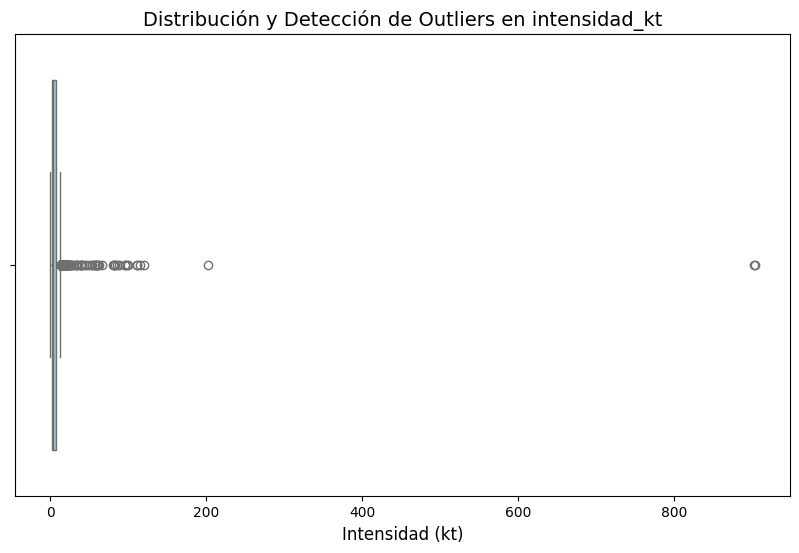

In [57]:
# Verificación outliers

# Configurar el tamaño de la figura (opcional, pero recomendado)
plt.figure(figsize=(10, 6))

# Crear el boxplot de la columna "intensidad_kt"
# Usamos orient='h' para que sea horizontal, suele facilitar la lectura de la dispersión
sns.boxplot(x=df_pre_copy["intensidad_kt"], color='skyblue')

# Añadir título y etiquetas
plt.title('Distribución y Detección de Outliers en intensidad_kt', fontsize=14)
plt.xlabel('Intensidad (kt)', fontsize=12)

# Mostrar el gráfico
plt.show()

# Noticia de vientos de bogota https://portal.gestiondelriesgo.gov.co/paginas/old_noticias/225.aspx
# https://portal.gestiondelriesgo.gov.co/paginas/old_noticias/225.aspx

# umbral para la sabana de Bogotá
umbral_maximo = 40

# Todo valor mayor al umbral se vuelve nulo ANTES de cualquier cálculo
df_pre_copy.loc[df_pre_copy['intensidad_kt'] > umbral_maximo, 'intensidad_kt'] = np.nan

### Datos faltantes

In [58]:
# 1. Crear el horario maestro (ejemplo: cada 1 hora)
rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('H'),
                              end=df_pre_copy.index.max().ceil('H'),
                              freq='1H')

# 2. Identificar qué horas del maestro no están en tus datos
horas_faltantes = rango_teorico.difference(df_pre_copy.index)
print(f"Total de reportes faltantes: {len(horas_faltantes)}")

# Identificar reportes que no ocurren exactamente en la hora (minuto != 0)
reportes_especiales = df_pre_copy[df_pre_copy.index.minute != 0]
print(f"Reportes extra encontrados: {len(reportes_especiales)}")

Total de reportes faltantes: 13337
Reportes extra encontrados: 9782


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16776\1832988519.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_teorico = pd.date_range(start=df_pre_copy.index.min().floor('H'),
C:\Users\Usuario\AppData\Local\Temp\ipykernel_16776\1832988519.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  end=df_pre_copy.index.max().ceil('H'),


#### Descomposicion de dirección e intensidad del viento

In [59]:
# =========================================================
# FASE 1: PREPARACIÓN DEL ÍNDICE Y CÁLCULO DE COMPONENTES
# =========================================================

# Asegurarnos de que el índice de dataset original es formato datetime
df_pre_copy.index = pd.to_datetime(df_pre_copy.index)

# PASO CRÍTICO: Redondear los reportes a la hora en punto más cercana.
# Esto sincroniza reportes emitidos al minuto 50-59 con la hora exacta.
df_pre_copy.index = df_pre_copy.index.round('H')

# Al redondear, un reporte regular y un reporte especial (SPECI) podrían caer
# en la misma hora. Conservamos el último (el más actualizado).
df_pre_copy = df_pre_copy[~df_pre_copy.index.duplicated(keep='last')]

# Calcular u y v desde cero:
df_pre_copy['u'] = -df_pre_copy['intensidad_kt'] * np.sin(np.radians(df_pre_copy['direccion']))
df_pre_copy['v'] = -df_pre_copy['intensidad_kt'] * np.cos(np.radians(df_pre_copy['direccion']))

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16776\564785493.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_pre_copy.index = df_pre_copy.index.round('H')


In [60]:
df_pre_copy.head()

,viento,temperatura,rocio,direccion,intensidad_kt,rafaga_kt,u,v
FECHA_REPORTE,,,,,,,,
2006-07-20 00:00:00,03004KT,13.0,8.0,30.0,4.0,0.0,-2.000000,-3.464102
2006-07-20 01:00:00,29004KT,11.0,10.0,290.0,4.0,0.0,3.758770,-1.368081
2006-07-20 05:00:00,VRB02KT,9.0,9.0,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 06:00:00,VRB02KT,8.0,8.0,290.0,2.0,0.0,1.879385,-0.684040
2006-07-20 07:00:00,VRB02KT,9.0,8.0,290.0,2.0,0.0,1.879385,-0.684040


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16776\4099261218.py:6: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  rango_completo = pd.date_range(start='2006-01-01', end='2026-12-31 23:00:00', freq='H')


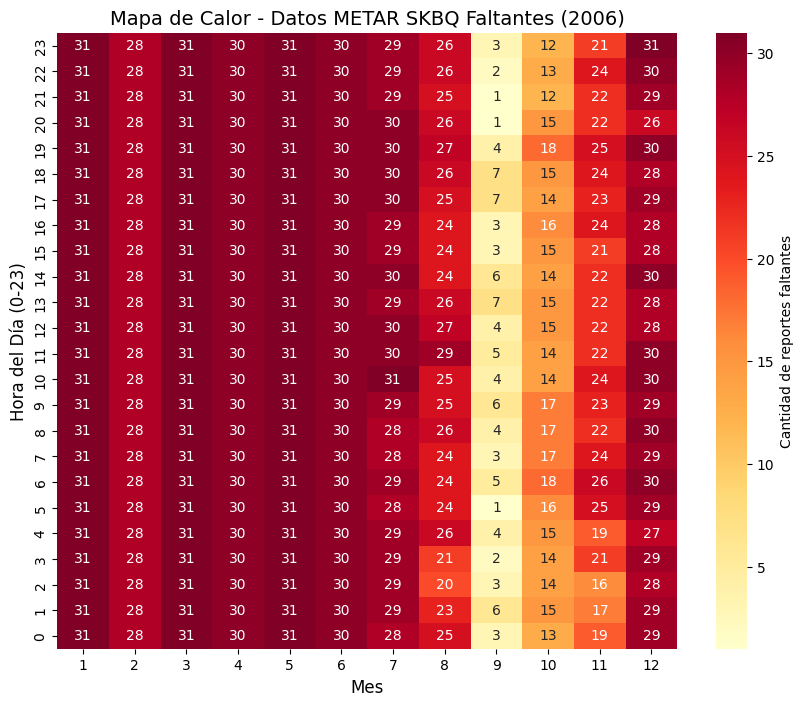

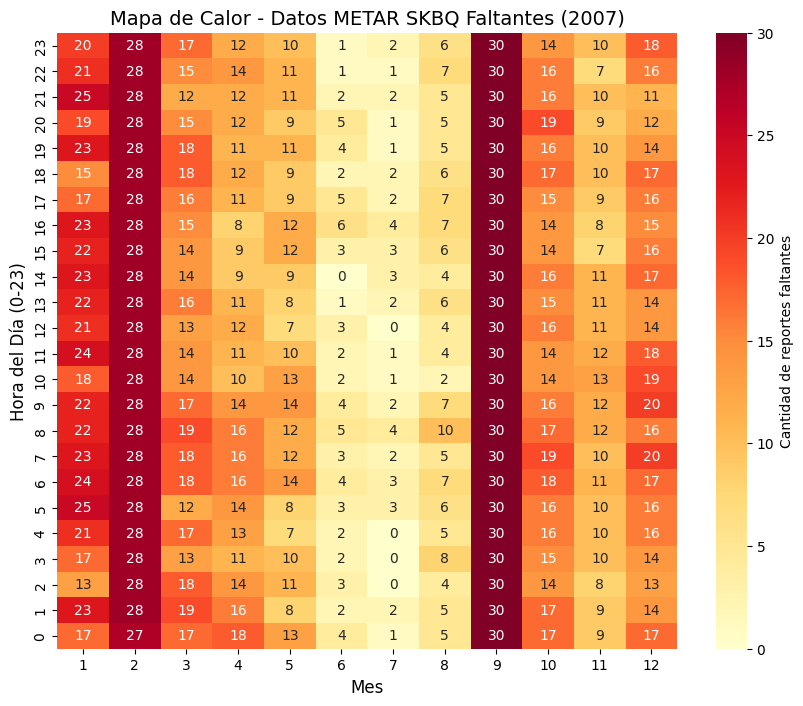

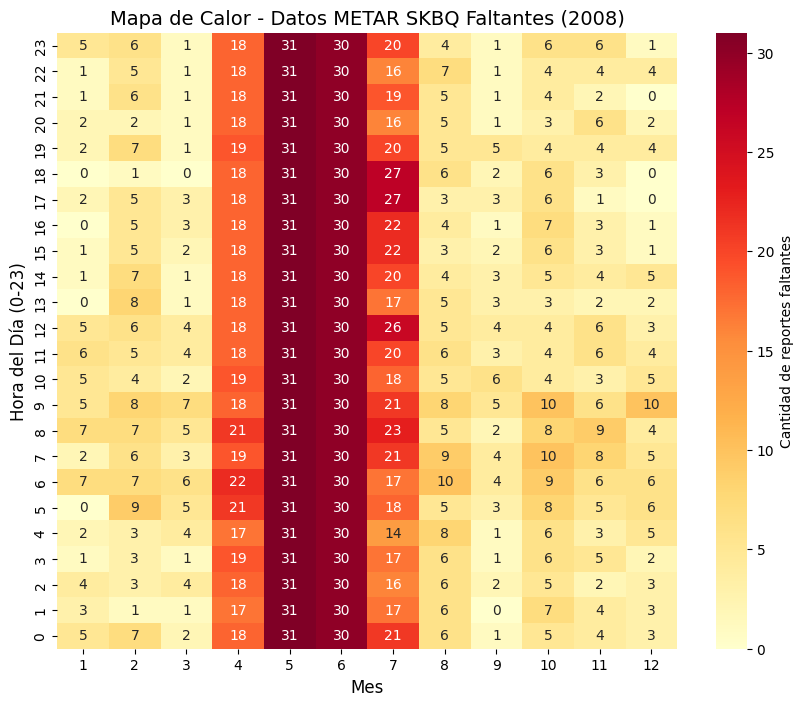

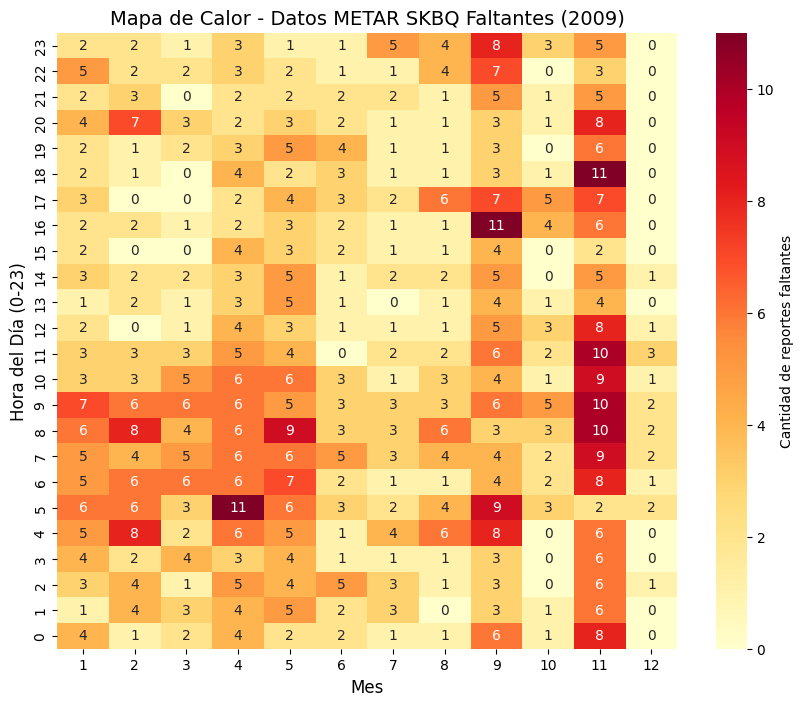

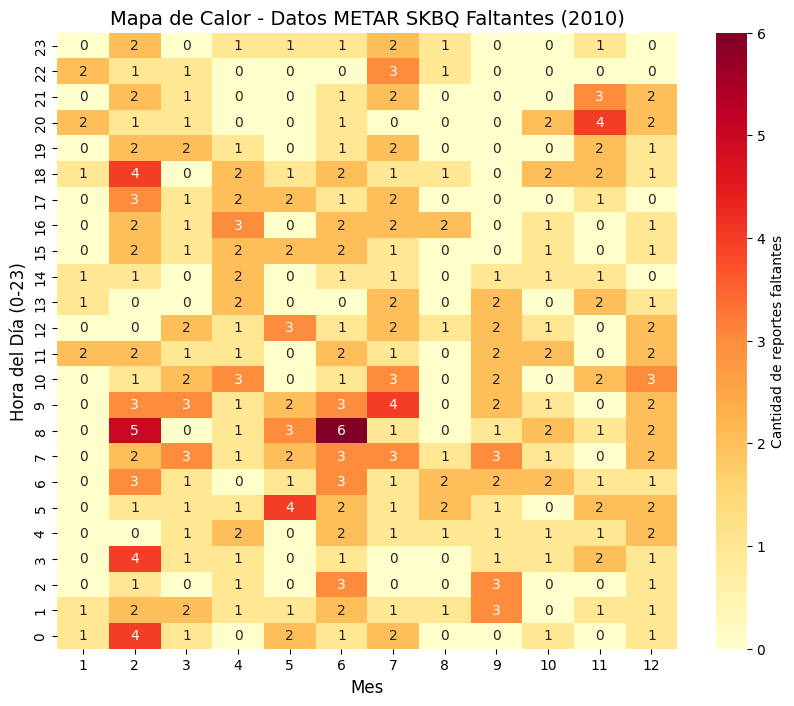

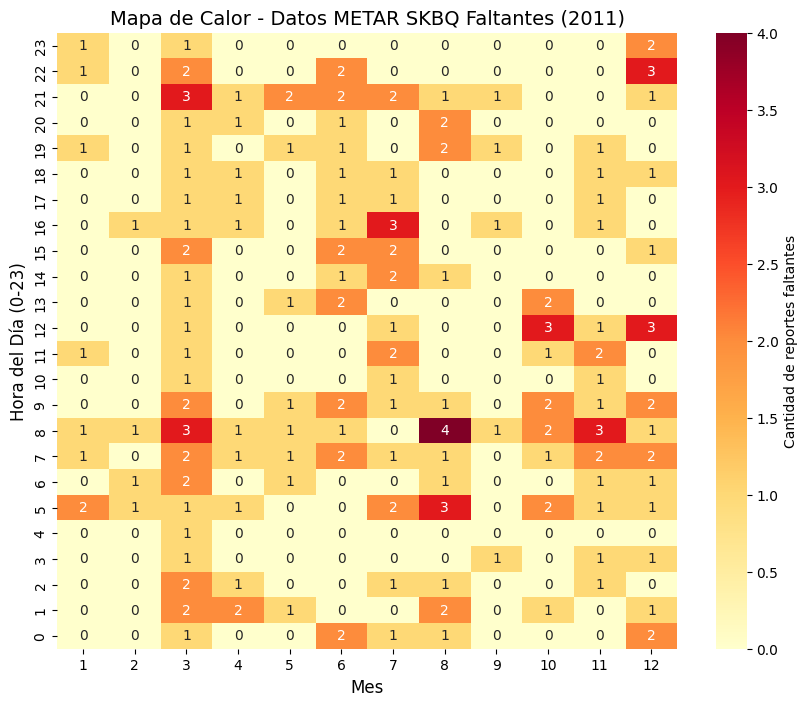

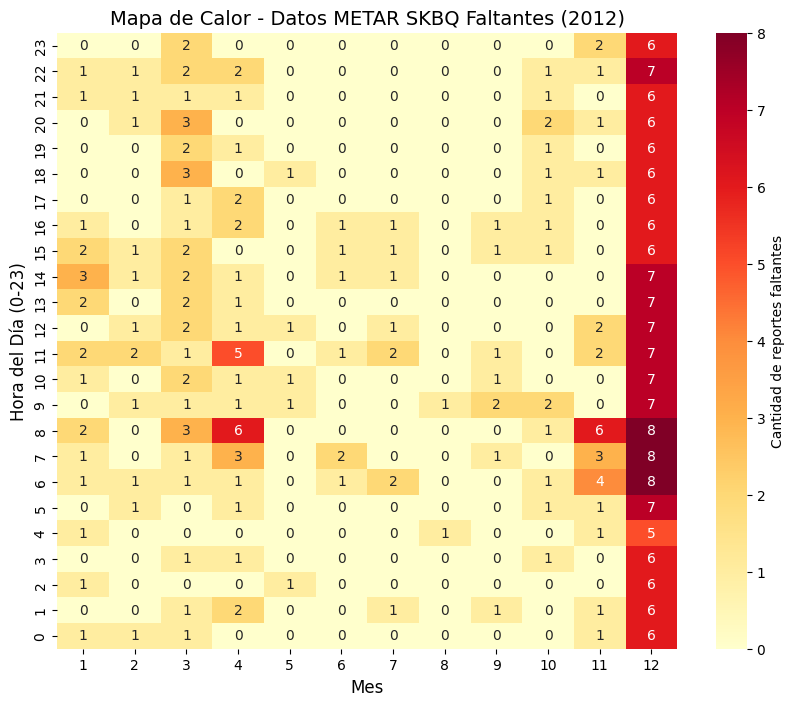

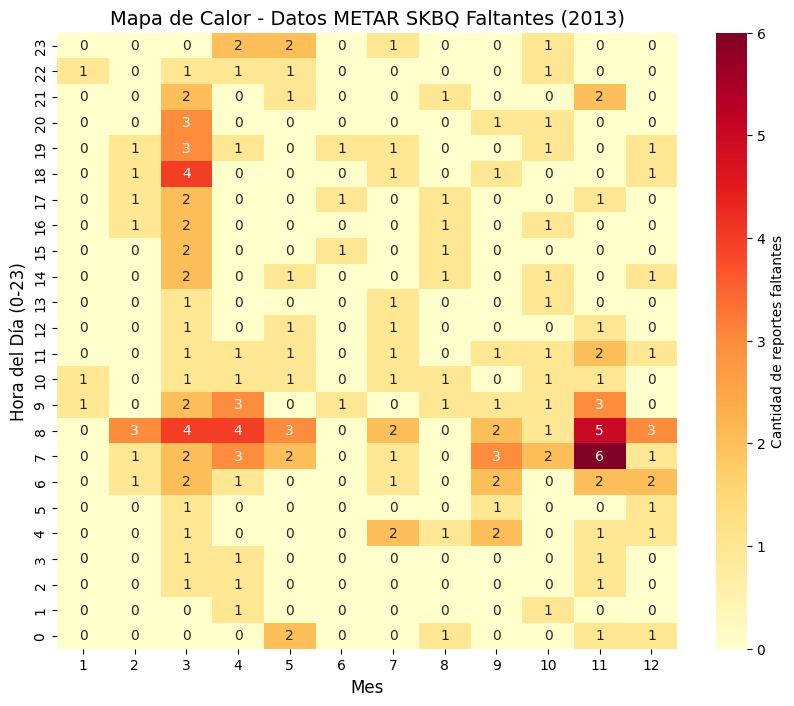

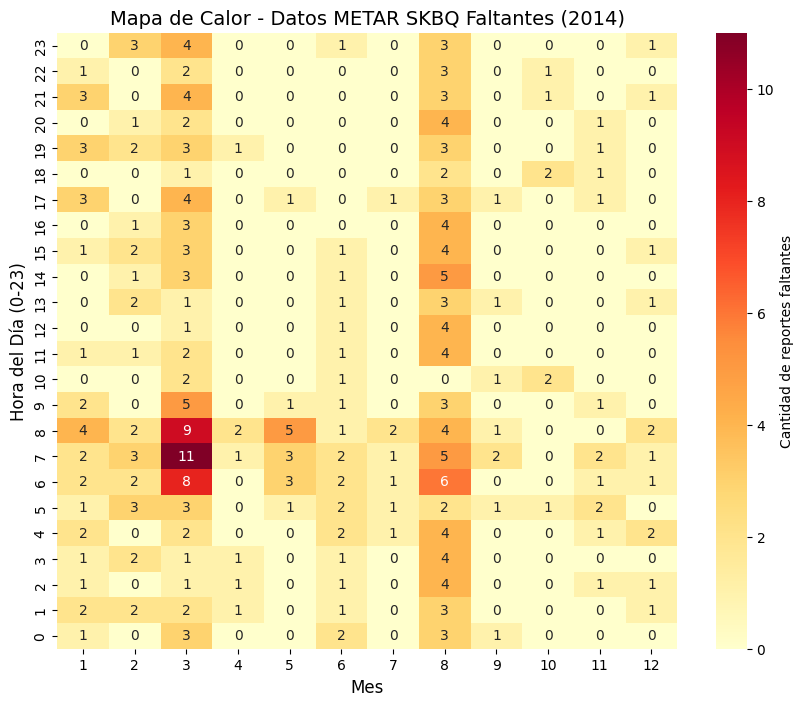

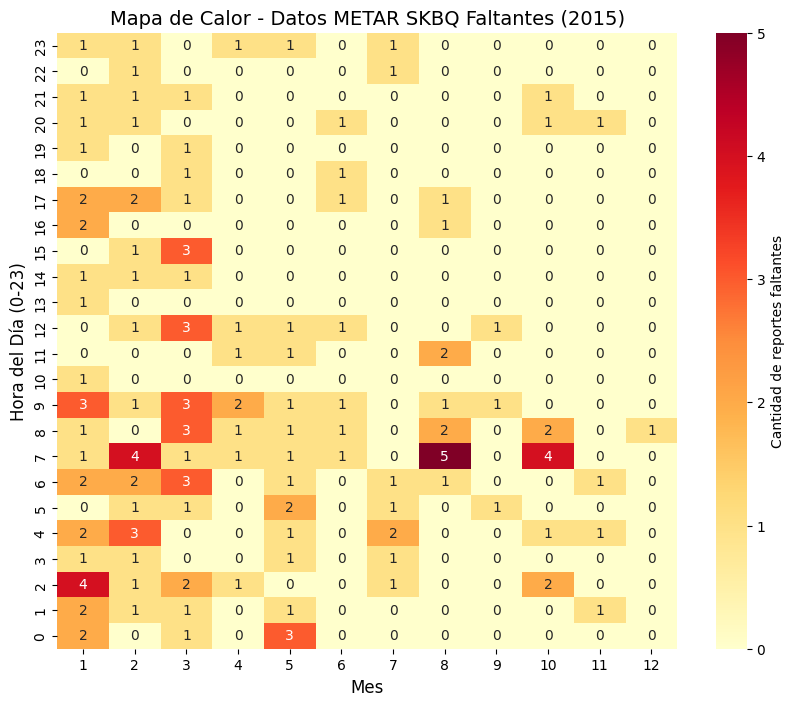

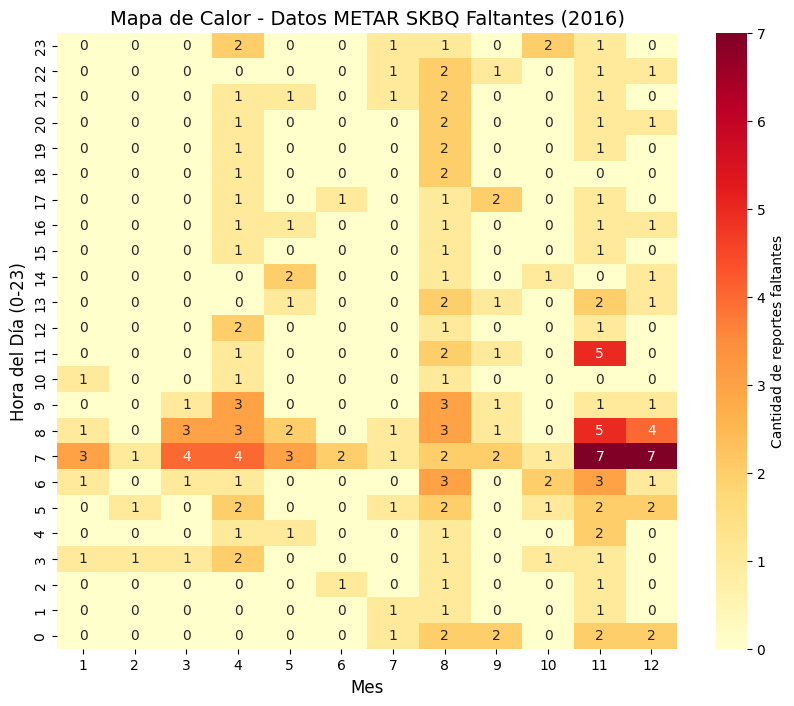

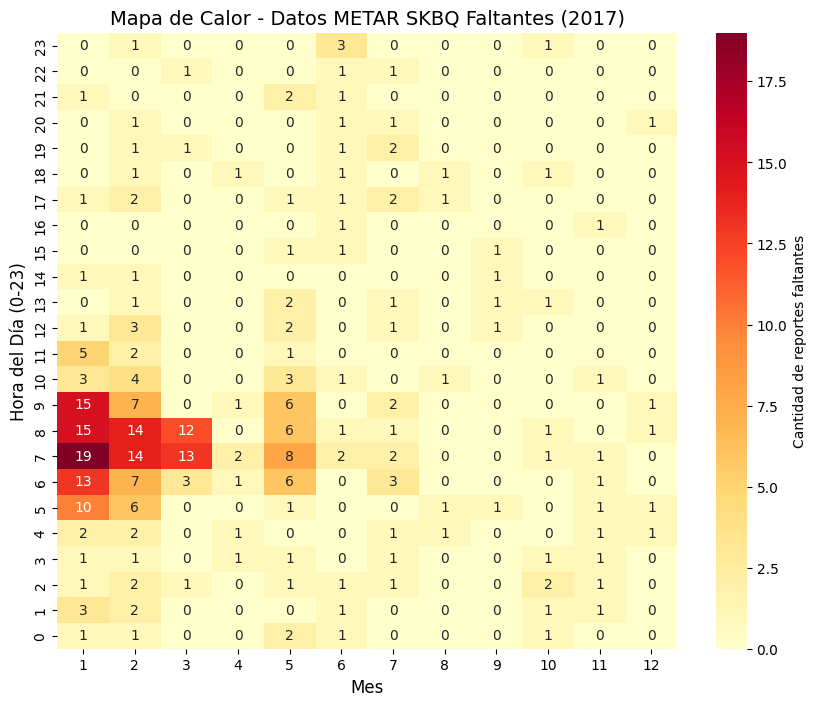

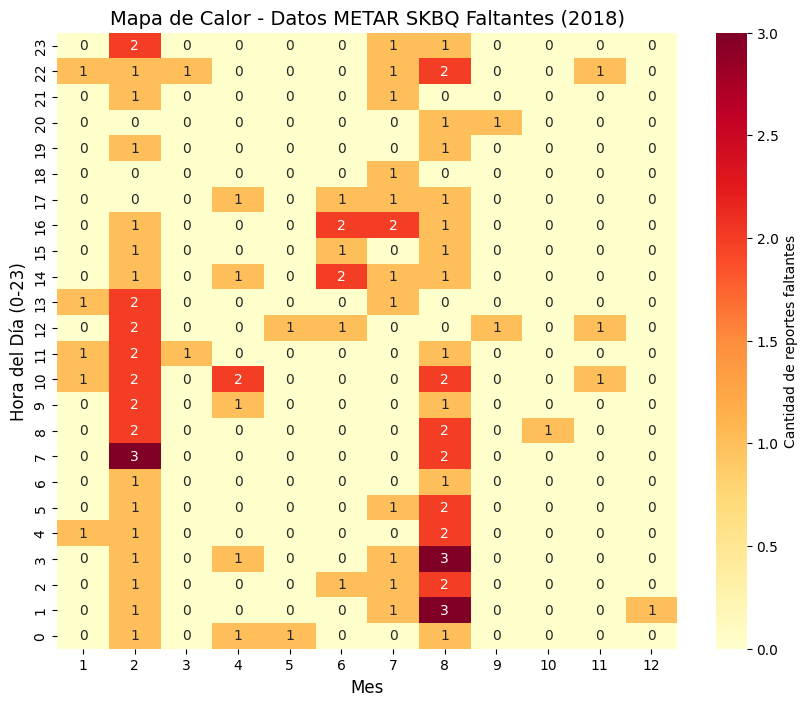

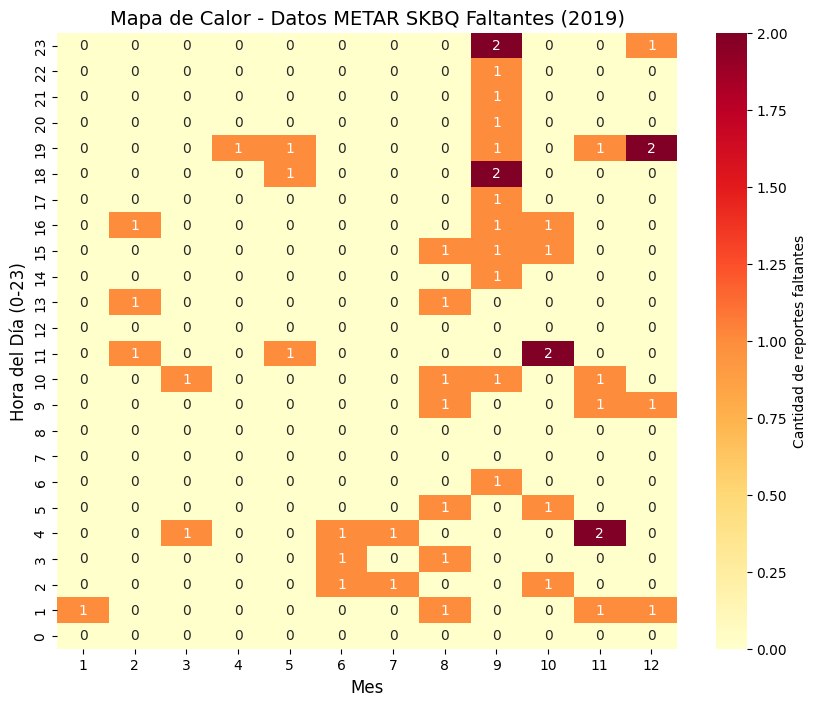

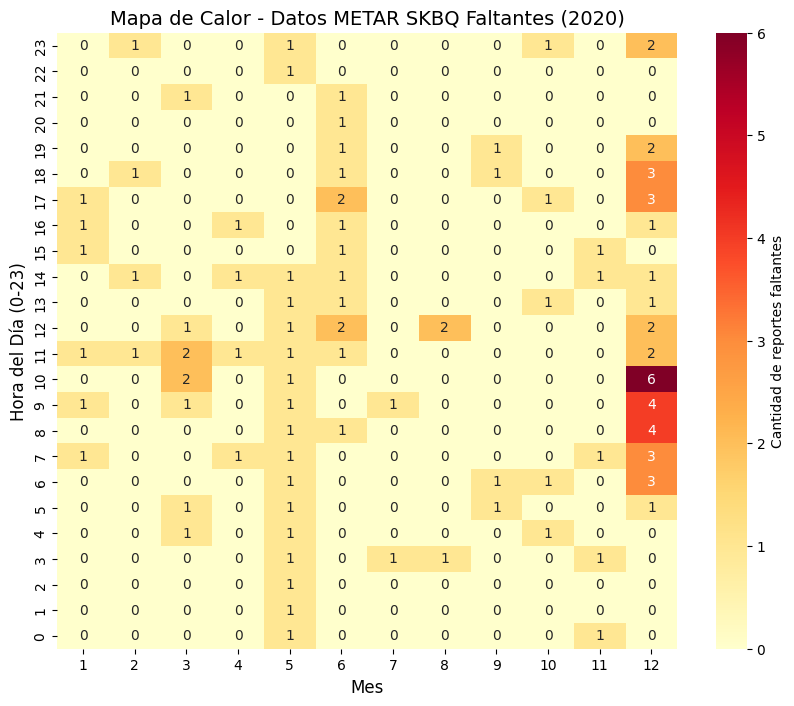

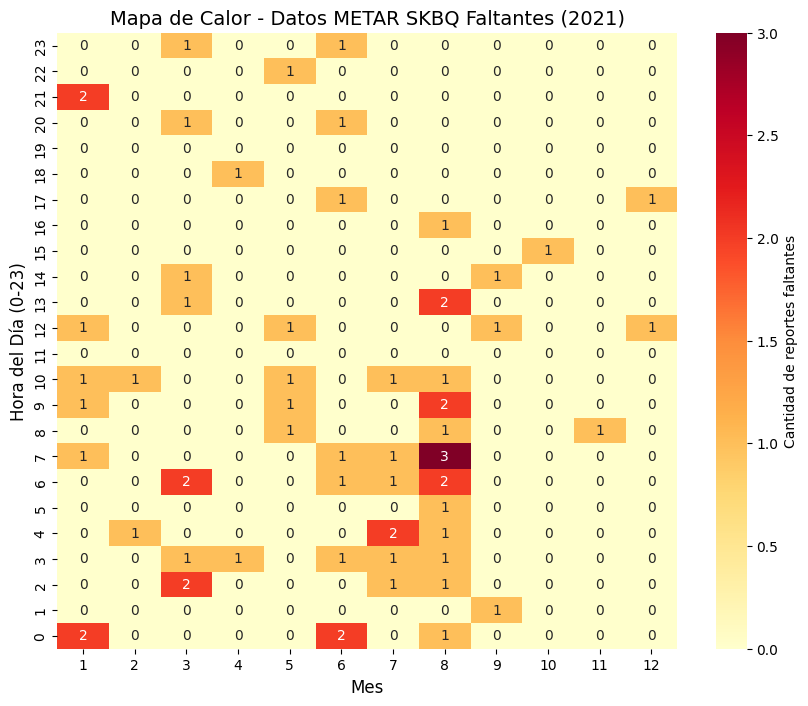

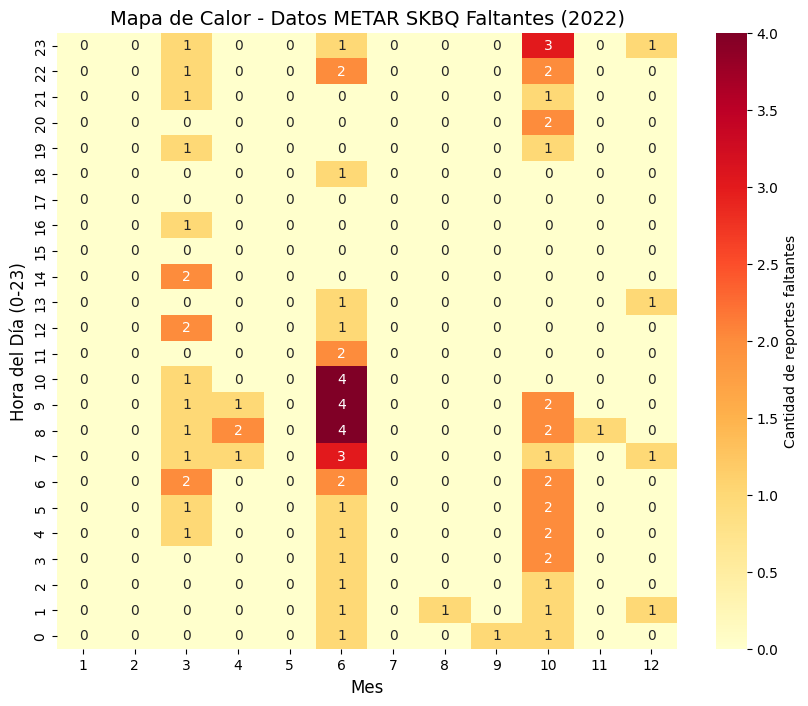

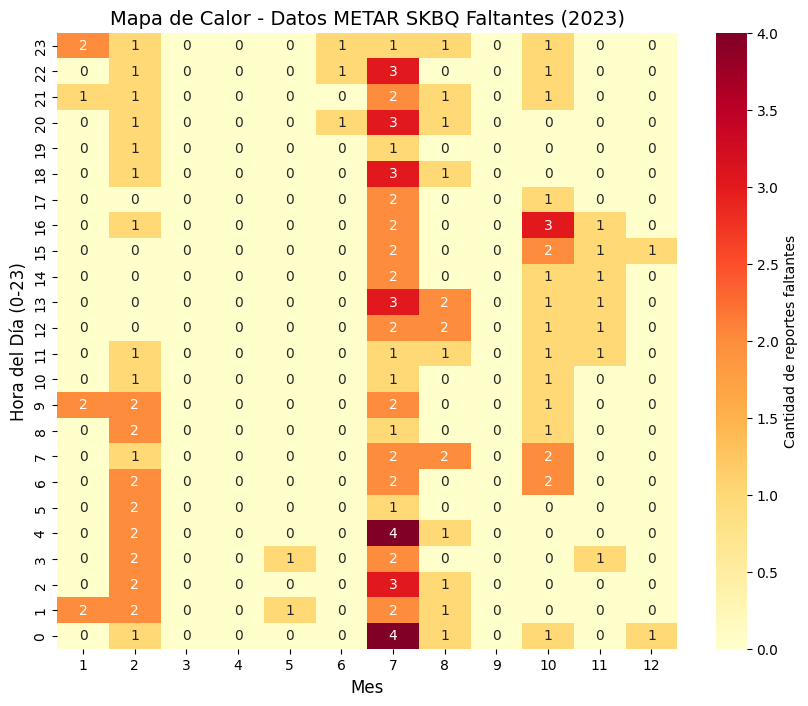

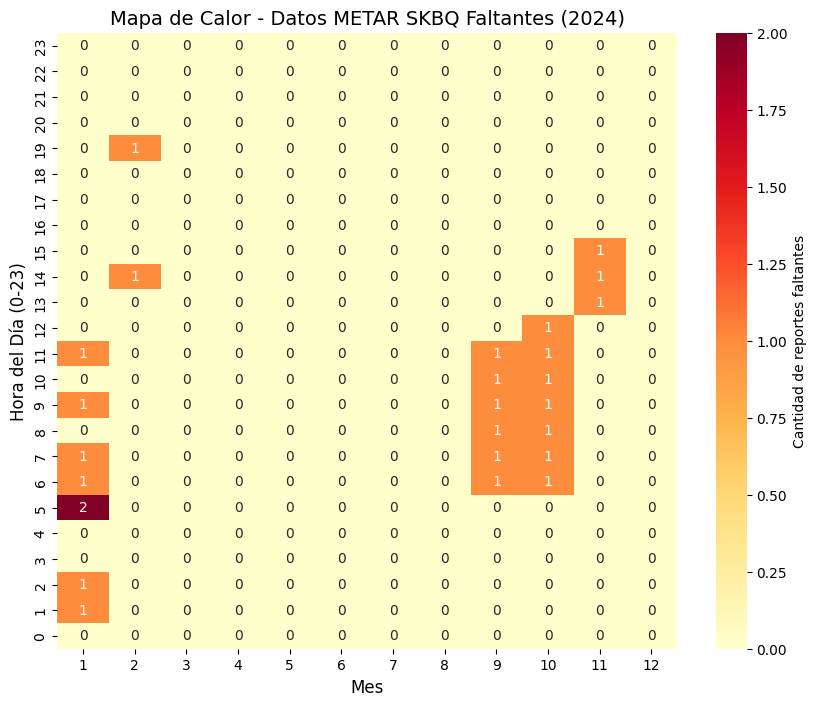

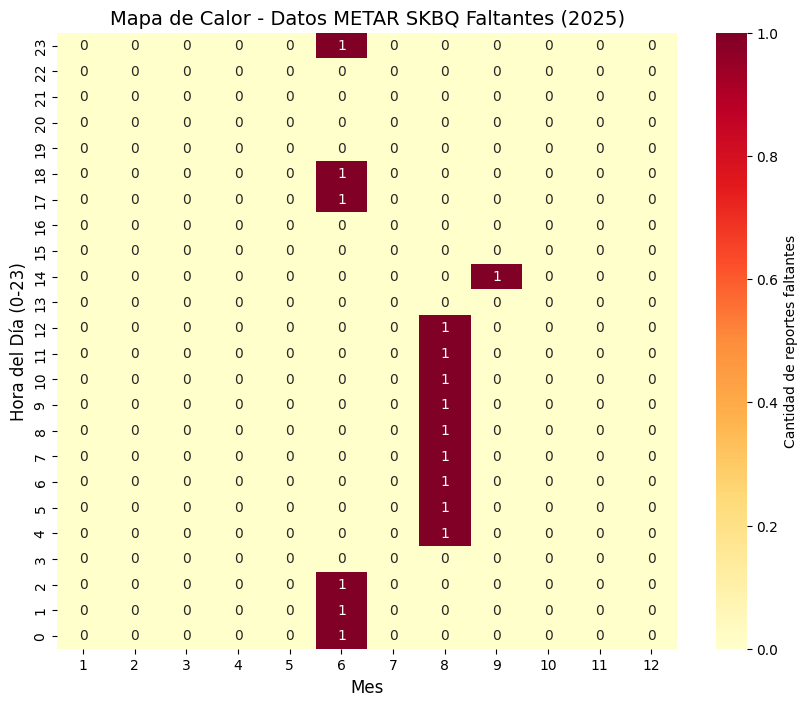

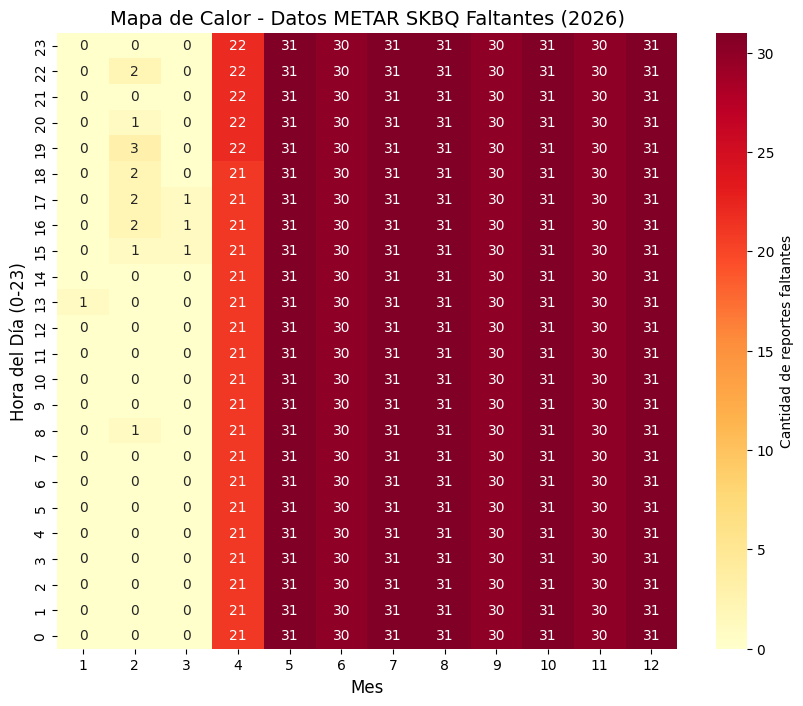

In [61]:
# =========================================================
# FASE 2: ALINEACIÓN Y DIAGNÓSTICO (HEATMAPS DE FALTANTES)
# =========================================================

# 1. Crear el índice perfecto y continuo para ventana de tiempo
rango_completo = pd.date_range(start='2006-01-01', end='2026-12-31 23:00:00', freq='H')

# 2. Reindexar: Aquí es donde se exponen matemáticamente los "huecos"
df_diagnostico = df_pre_copy.reindex(rango_completo)

# 3. Extraer metadatos temporales para los gráficos
df_faltantes = df_diagnostico['u'].isna().to_frame(name='es_faltante')
df_faltantes['Año'] = df_faltantes.index.year
df_faltantes['Mes'] = df_faltantes.index.month
df_faltantes['Hora'] = df_faltantes.index.hour

# 4. Graficar los heatmaps anuales para el aeropuerto SKBO
df_solo_faltantes = df_faltantes[df_faltantes['es_faltante'] == True]

for anio in range(2006, 2027):
    data_anio = df_solo_faltantes[df_solo_faltantes['Año'] == anio]

    if data_anio.empty:
        continue

    pivot = pd.pivot_table(data_anio, values='es_faltante', index='Hora',
                           columns='Mes', aggfunc='count', fill_value=0)
    pivot = pivot.reindex(index=range(24), columns=range(1, 13), fill_value=0)

    plt.figure(figsize=(10, 8))
    sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt="d",
                cbar_kws={'label': 'Cantidad de reportes faltantes'})
    plt.title(f'Mapa de Calor - Datos METAR SKBQ Faltantes ({anio})', fontsize=14)
    plt.xlabel('Mes', fontsize=12)
    plt.ylabel('Hora del Día (0-23)', fontsize=12)
    plt.gca().invert_yaxis()
    plt.show()

Los mejores datos a tomar para que luego de la imputacion ,no se presente mucho sesgo es desde el 2013 (inclusive).

In [74]:
# 1. Transformación Vectorial (u, v) - HACER ANTES DEL RESAMPLE
# u = componente Este-Oeste, v = componente Norte-Sur

radianes = df_pre_copy['direccion'] * (np.pi / 180)
df_pre_copy['u'] = -df_pre_copy['intensidad_kt'] * np.sin(radianes)
df_pre_copy['v'] = -df_pre_copy['intensidad_kt'] * np.cos(radianes)

# 2. Definir reglas de agregación para tus columnas
reglas = {
    'u': 'mean',          # Promedio de la componente zonal
    'v': 'mean',          # Promedio de la componente meridional
    'intensidad_kt': 'mean',
    'rafaga_kt': 'max',    # Capturamos la ráfaga más fuerte de la hora
    'temperatura': 'mean', # Promedio de temperatura
    'rocio': 'mean'       # Promedio de punto de rocío
}

# 3. Forzar la frecuencia horaria (Resample)
df_modelo = df_pre_copy.resample('1H').agg(reglas)

# 4. Mantener la continuidad para el modelo (Interpolación)
# El LSTM requiere que no existan huecos en la secuencia
df_modelo['u'] = df_modelo['u'].interpolate(method='linear')
df_modelo['v'] = df_modelo['v'].interpolate(method='linear')
df_modelo['intensidad_kt'] = df_modelo['intensidad_kt'].interpolate(method='linear')
df_modelo['rafaga_kt'] = df_modelo['rafaga_kt'].fillna(0) # Si no hay reporte, rafaga es 0
# Conservar las columnas 'temperatura' y 'rocio' en df_modelo
df_modelo['temperatura'] = df_modelo['temperatura'].interpolate(method='linear')
df_modelo['rocio'] = df_modelo['rocio'].interpolate(method='linear')

C:\Users\Usuario\AppData\Local\Temp\ipykernel_16776\658338961.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_modelo = df_pre_copy.resample('1H').agg(reglas)


In [75]:
# Muestra la sumatoria de valores NaN en cada columna
print("Cantidad de valores faltantes por columna:")
print(df_modelo.isnull().sum())

# Verifica si la frecuencia horaria es estrictamente regular
print("\n¿Es el índice estrictamente regular (1H)?:", pd.infer_freq(df_modelo.index) == 'H')

Cantidad de valores faltantes por columna:
u                0
v                0
intensidad_kt    0
rafaga_kt        0
temperatura      0
rocio            0
dtype: int64

¿Es el índice estrictamente regular (1H)?: False


In [77]:
# 1. Asignar la frecuencia horaria de forma estricta
df_modelo = df_modelo.asfreq('H')

# 2. Verificar que la etiqueta 'freq' se haya asignado correctamente
print("Frecuencia oficial del índice:", df_modelo.index.freq)

Frecuencia oficial del índice: <Hour>


C:\Users\Usuario\AppData\Local\Temp\ipykernel_16776\567216096.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_modelo = df_modelo.asfreq('H')


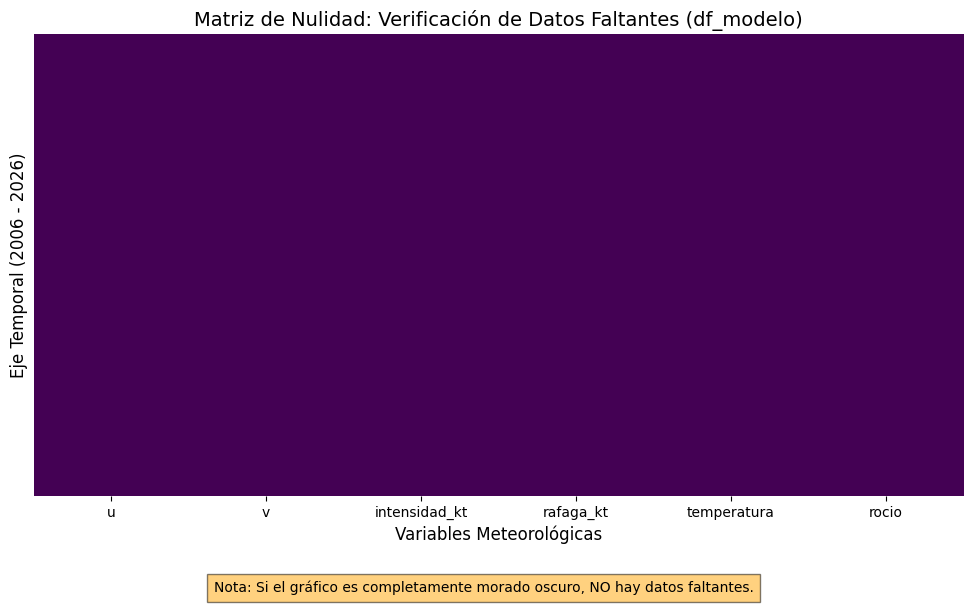

In [78]:
# Configurar el tamaño del gráfico
plt.figure(figsize=(12, 6))

# Crear un heatmap directamente sobre los valores booleanos de df.isnull()
# cbar=False quita la barra lateral, yticklabels=False oculta las miles de fechas del eje Y
sns.heatmap(df_modelo.isnull(), cbar=False, cmap='viridis', yticklabels=False)

plt.title('Matriz de Nulidad: Verificación de Datos Faltantes (df_modelo)', fontsize=14)
plt.xlabel('Variables Meteorológicas', fontsize=12)
plt.ylabel('Eje Temporal (2006 - 2026)', fontsize=12)

# Añadir un texto explicativo dentro del gráfico
plt.figtext(0.5, -0.05, "Nota: Si el gráfico es completamente morado oscuro, NO hay datos faltantes.",
            ha="center", fontsize=10, bbox={"facecolor":"orange", "alpha":0.5, "pad":5})

plt.show()

In [83]:
# Filtrar desde 2013
df_var = df_modelo.loc['2013-01-01':].reset_index()
df_var = df_modelo.loc['2013-01-01':, ['u', 'v', 'intensidad_kt','temperatura','rocio', 'rafaga_kt']].reset_index()

In [84]:
# "/content/drive/MyDrive/MAESTRIA/
ruta_exportacion = 'DATOS_ENTRENAMIENTO_con_temp_roc.csv'

# Verificar que el directorio existe (crearlo si no existe)
#import os
#directorio = os.path.dirname(ruta_exportacion)
#if not os.path.exists(directorio):
#    os.makedirs(directorio, exist_ok=True)
#    print(f" Directorio creado: {directorio}")

# Exportar a CSV
df_var.to_csv(ruta_exportacion, index=False)

In [85]:
df_var

,FECHA_REPORTE,u,v,intensidad_kt,temperatura,rocio,rafaga_kt
0,2013-01-01 00:00:00,-5.209445e-01,-2.954423,3.0,14.0,6.0,0.0
1,2013-01-01 01:00:00,-2.500000e+00,-4.330127,5.0,13.0,7.0,0.0
2,2013-01-01 02:00:00,-2.819078e+00,-1.026060,3.0,13.0,7.0,0.0
3,2013-01-01 03:00:00,-1.500000e+00,-2.598076,3.0,10.0,7.0,0.0
4,2013-01-01 04:00:00,-2.000000e+00,-3.464102,4.0,9.0,7.0,0.0
...,...,...,...,...,...,...,...
116318,2026-04-09 14:00:00,-4.788282e+00,13.155697,14.0,17.0,10.0,25.0
116319,2026-04-09 15:00:00,-8.500000e+00,14.722432,17.0,18.0,10.0,0.0
116320,2026-04-09 16:00:00,-1.836970e-15,15.000000,15.0,17.0,10.0,0.0
116321,2026-04-09 17:00:00,-5.500000e+00,9.526279,11.0,17.0,10.0,0.0


# PRUEBA DE MODELOS

In [86]:
# EXTRACION DE DATA LISTA PARA LOS MODELOS
df_var_drive = pd.read_csv('C:\\Users\\Usuario\\Documents\\GitHub\\PROYECTO_MAESTRÍA\\Prediccion-Cizalladura-SKBQ\\docs\\notebooks\\DATOS_ENTRENAMIENTO_con_temp_roc.csv')

In [87]:
df_var = df_var_drive[["FECHA_REPORTE", "u", "v", "rafaga_kt", "temperatura","rocio"]].copy()

In [88]:
df_var.head()

,FECHA_REPORTE,u,v,rafaga_kt,temperatura,rocio
0,2013-01-01 00:00:00,-0.520945,-2.954423,0.0,14.0,6.0
1,2013-01-01 01:00:00,-2.500000,-4.330127,0.0,13.0,7.0
2,2013-01-01 02:00:00,-2.819078,-1.026060,0.0,13.0,7.0
3,2013-01-01 03:00:00,-1.500000,-2.598076,0.0,10.0,7.0
4,2013-01-01 04:00:00,-2.000000,-3.464102,0.0,9.0,7.0


##### VAR

In [89]:
# del dataset df_var por favor poner FECHA_REPORTE como indice y eliminar la columna de FECHA_REPORTE
df_var.set_index('FECHA_REPORTE', inplace=True)

In [90]:
df_var.head()

,u,v,rafaga_kt,temperatura,rocio
FECHA_REPORTE,,,,,
2013-01-01 00:00:00,-0.520945,-2.954423,0.0,14.0,6.0
2013-01-01 01:00:00,-2.500000,-4.330127,0.0,13.0,7.0
2013-01-01 02:00:00,-2.819078,-1.026060,0.0,13.0,7.0
2013-01-01 03:00:00,-1.500000,-2.598076,0.0,10.0,7.0
2013-01-01 04:00:00,-2.000000,-3.464102,0.0,9.0,7.0


In [91]:
def check_stationarity(df, columns):
    results = {}
    for col in columns:
        print(f"--- Análisis de Estacionariedad para: {col} ---")
        # Realizamos el test ADF
        # autolag='AIC' elige el mejor rezago para la prueba estadística
        result = adfuller(df[col].dropna(), autolag='AIC')
        
        p_value = result[1]
        is_stationary = p_value < 0.05
        
        results[col] = {'p-value': p_value, 'Stationary': is_stationary}
        
        print(f'Estadístico ADF: {result[0]:.8f}')
        print(f'p-value: {p_value:.8e}')
        print(f'¿Es estacionaria? {"SÍ" if is_stationary else "NO"}')
        print("-" * 45)
        
    return results

def analizar_estacionalidad(df, columna, freq=24):
    # Usamos modelo aditivo porque u y v oscilan alrededor de 0
    res = seasonal_decompose(df[columna], model='additive', period=freq)
    
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
    res.observed.plot(ax=ax1, title=f'Análisis de {columna}')
    ax1.set_ylabel('Original')
    res.trend.plot(ax=ax2)
    ax2.set_ylabel('Tendencia')
    res.seasonal.plot(ax=ax3)
    ax3.set_ylabel('Estacionalidad (Diaria)')
    plt.tight_layout()
    plt.show()
    
    # Retornamos el residuo para análisis posterior
    return res.resid

def graficar_correlaciones(df, columna, lags=48):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
    # ACF: Detecta la persistencia y ciclos estacionales (24h, 48h...)
    plot_acf(df[columna].dropna(), lags=lags, ax=ax1, title=f'ACF - {columna}')
    
    # PACF: Ayuda a determinar el orden p del modelo (usa 'yw' o 'ols')
    # Nota: Agregamos .dropna() por seguridad
    plot_pacf(df[columna].dropna(), lags=lags, ax=ax2, title=f'PACF - {columna}', method='yw')
    
    plt.tight_layout()
    plt.show()

In [92]:
# Definimos las variables de interés
cols_to_test = ['u', 'v','rafaga_kt', 'temperatura','rocio']
estacionariedad_res = check_stationarity(df_var, cols_to_test)

--- Análisis de Estacionariedad para: u ---
Estadístico ADF: -21.28644303
p-value: 0.00000000e+00
¿Es estacionaria? SÍ
---------------------------------------------
--- Análisis de Estacionariedad para: v ---
Estadístico ADF: -22.89967845
p-value: 0.00000000e+00
¿Es estacionaria? SÍ
---------------------------------------------
--- Análisis de Estacionariedad para: rafaga_kt ---
Estadístico ADF: -44.46163233
p-value: 0.00000000e+00
¿Es estacionaria? SÍ
---------------------------------------------
--- Análisis de Estacionariedad para: temperatura ---
Estadístico ADF: -28.31624256
p-value: 0.00000000e+00
¿Es estacionaria? SÍ
---------------------------------------------
--- Análisis de Estacionariedad para: rocio ---
Estadístico ADF: -21.48749530
p-value: 0.00000000e+00
¿Es estacionaria? SÍ
---------------------------------------------


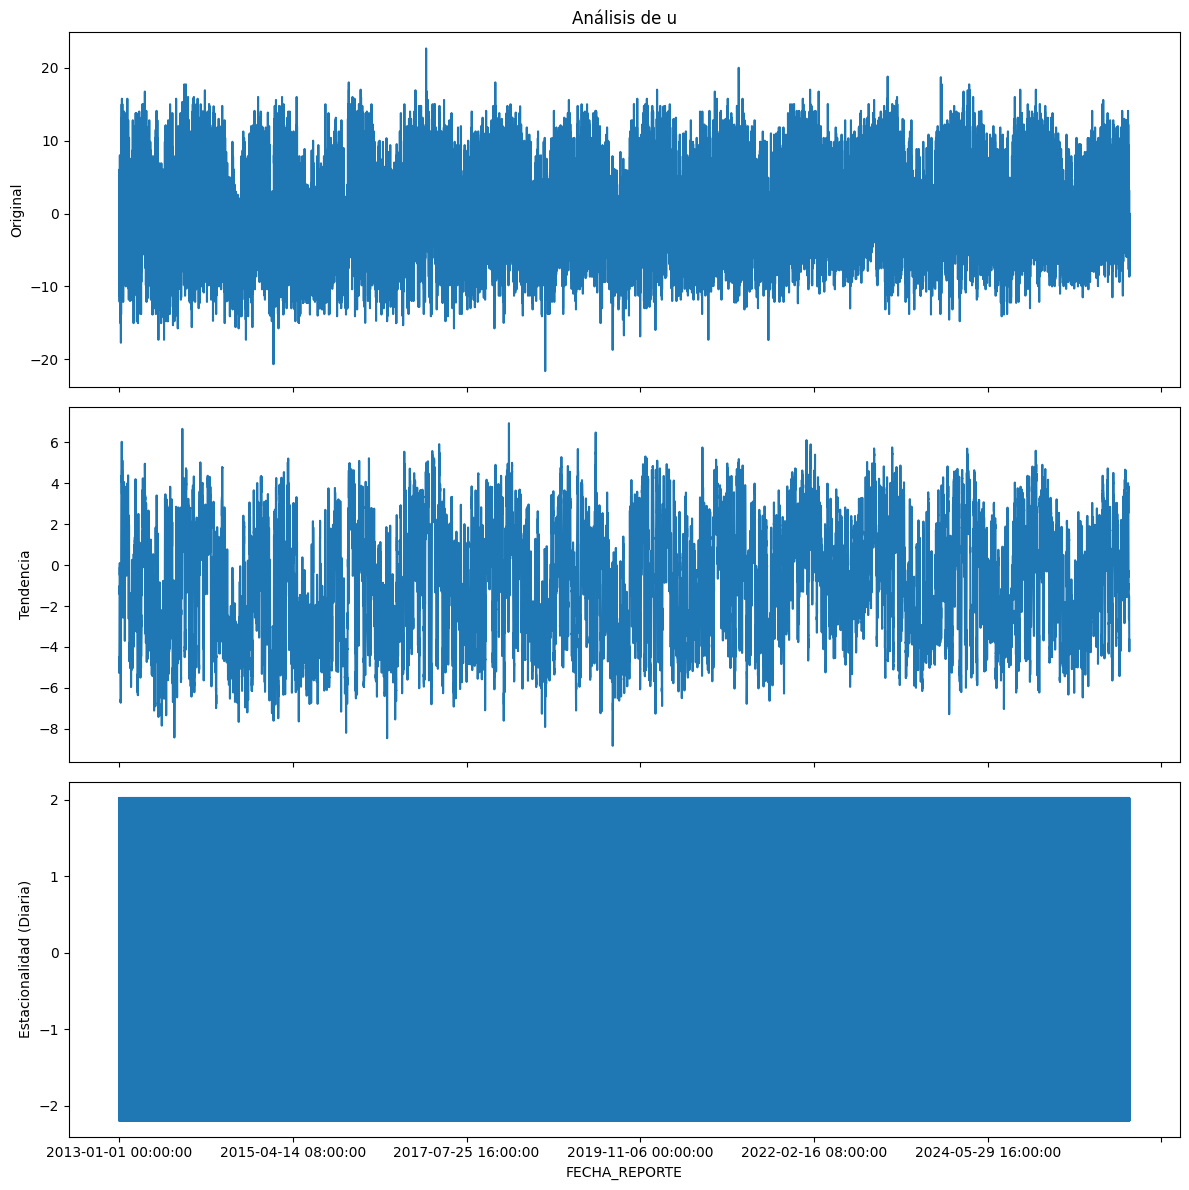

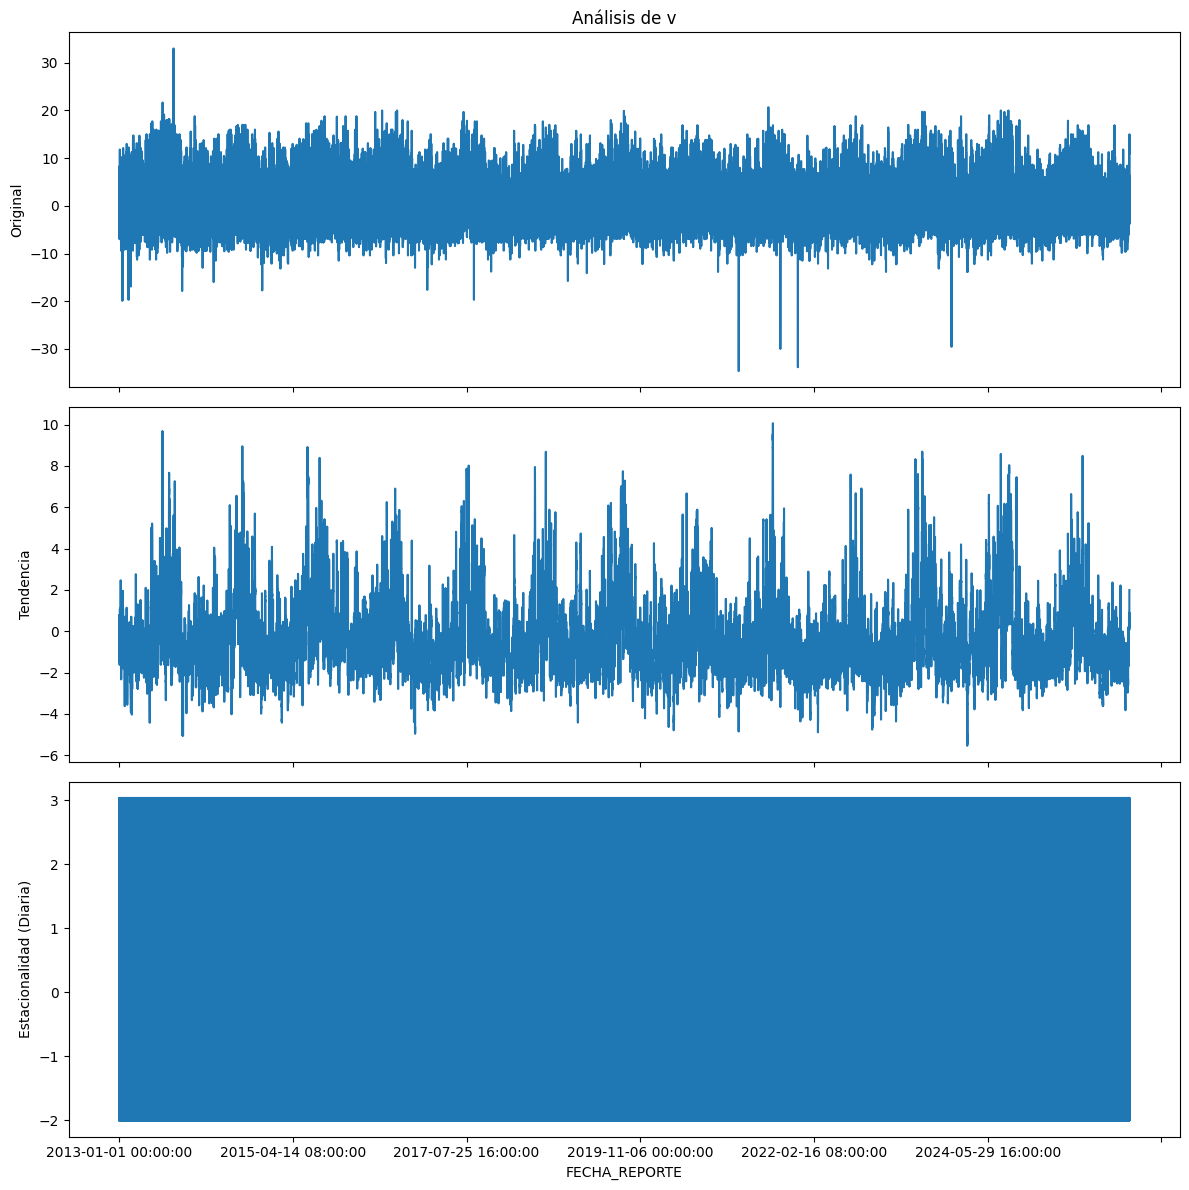

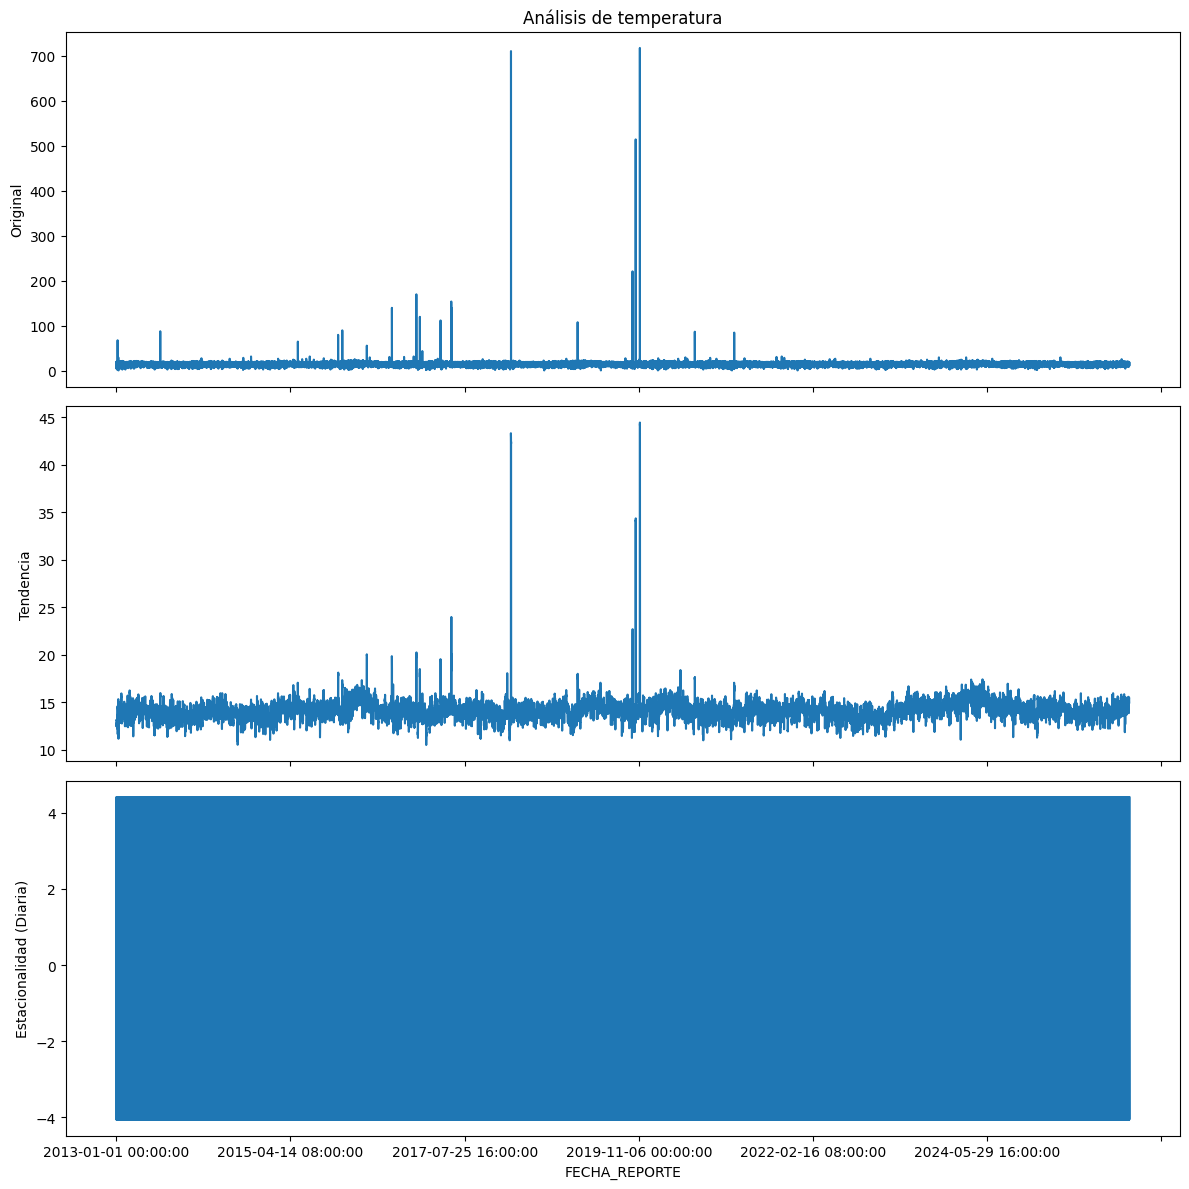

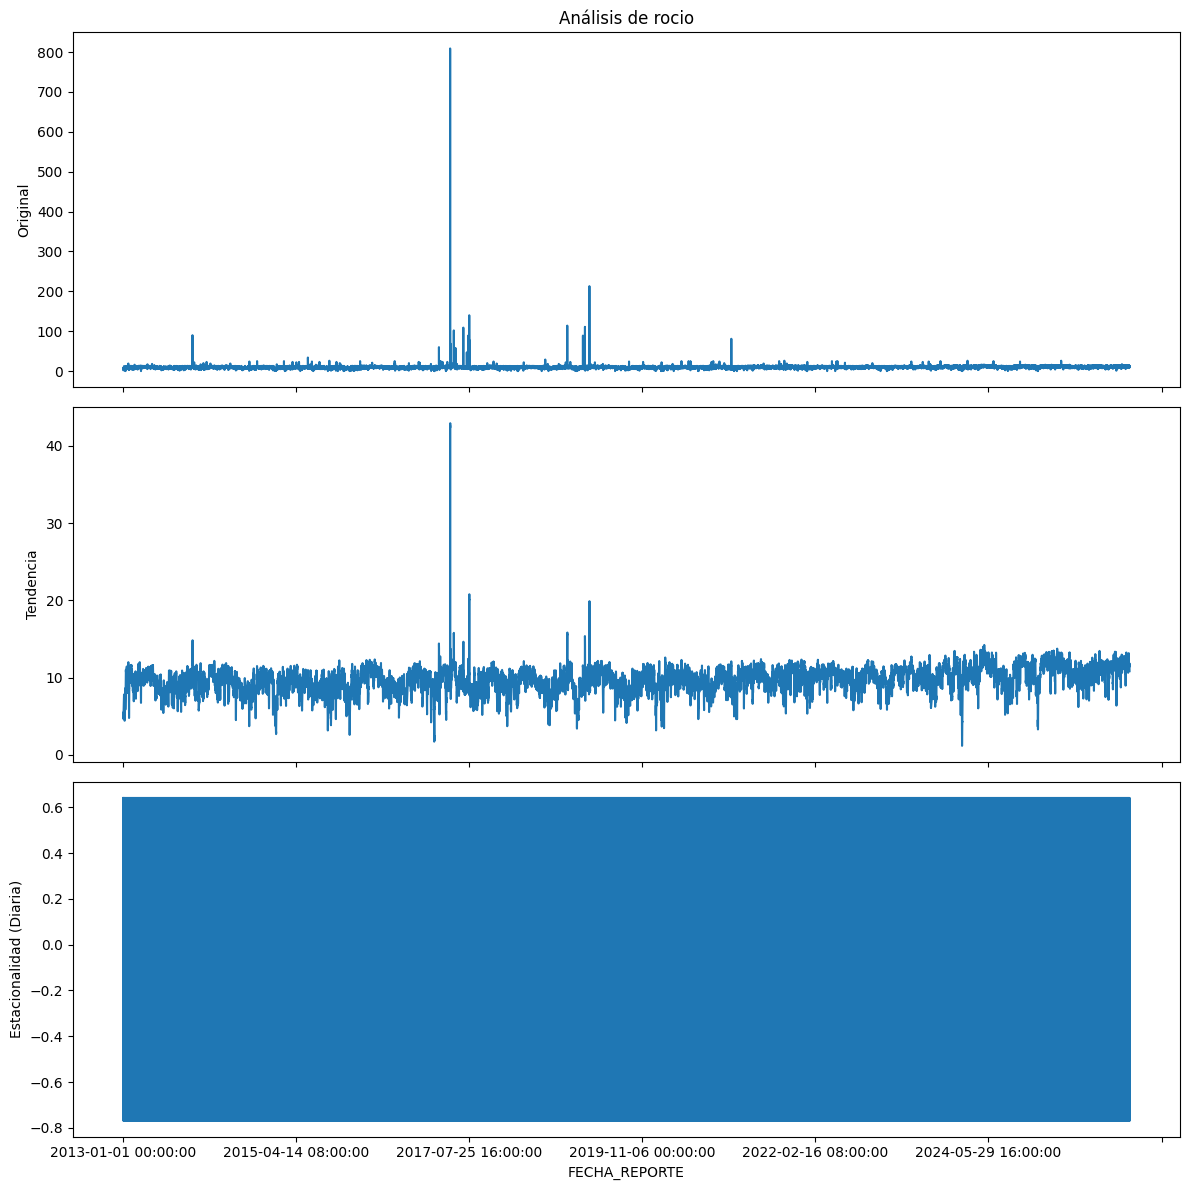

In [93]:
# Ejecútalo para 'u' y 'v'
residuo_u = analizar_estacionalidad(df_var, 'u')
residuo_v = analizar_estacionalidad(df_var, 'v')
residuo_temp = analizar_estacionalidad(df_var, 'temperatura')
residuo_rocio = analizar_estacionalidad(df_var, 'rocio')

1. El "Bloque" de Estacionalidad: 

En ambos gráficos (u y v), la sección de Estacionalidad (Diaria) aparece como un bloque sólido de color azul.

Deducción: Esto no es un error, es señal de una estacionalidad de alta frecuencia extremadamente persistente. Indica que el ciclo de 24 horas (brisas térmicas día/noche) tiene una amplitud constante de aproximadamente $\pm 2$ a $\pm 3$ unidades a lo largo de los 13 años.

Impacto en el VAR: Tu modelo necesitará capturar esta "memoria" de corto plazo. Si quieres predecir a 6 horas, el modelo debe entender en qué fase de este ciclo diario se encuentra.

2. La Tendencia en v: El Ciclo AnualObserva la gráfica de Tendencia de la componente v:

Deducción: A diferencia de u, donde la tendencia parece un ruido de baja frecuencia, en v se observa un patrón sinusoidal claro y repetitivo con picos cada año.
Explicación Física: Esto sugiere que la componente Norte-Sur del viento en tu ubicación tiene una dependencia estacional anual muy marcada (posiblemente asociada a la migración de la Zona de Convergencia Intertropical - ZCIT en Colombia).
Impacto en el VAR: El VAR por sí solo (con pocos lags) es excelente para la dinámica de corto plazo, pero le cuesta ver ciclos tan largos (anuales). Sin embargo, al ser datos para predicción de 6 horas, la dinámica horaria dominará sobre la anual.

3. Estacionariedad Visual y Volatilidad

Deducción: Las gráficas Originales confirman lo que dijo el test ADF: las series oscilan alrededor de una media constante (cercana a cero). No hay una deriva (drift) que se escape al infinito.
Outliers: En v se ven picos aislados que superan las 30 unidades (posiblemente eventos meteorológicos extremos o tormentas). El VAR es sensible a estos valores atípicos, por lo que la normalización que mencionaste será vital para que estos picos no "jalen" demasiado los coeficientes.

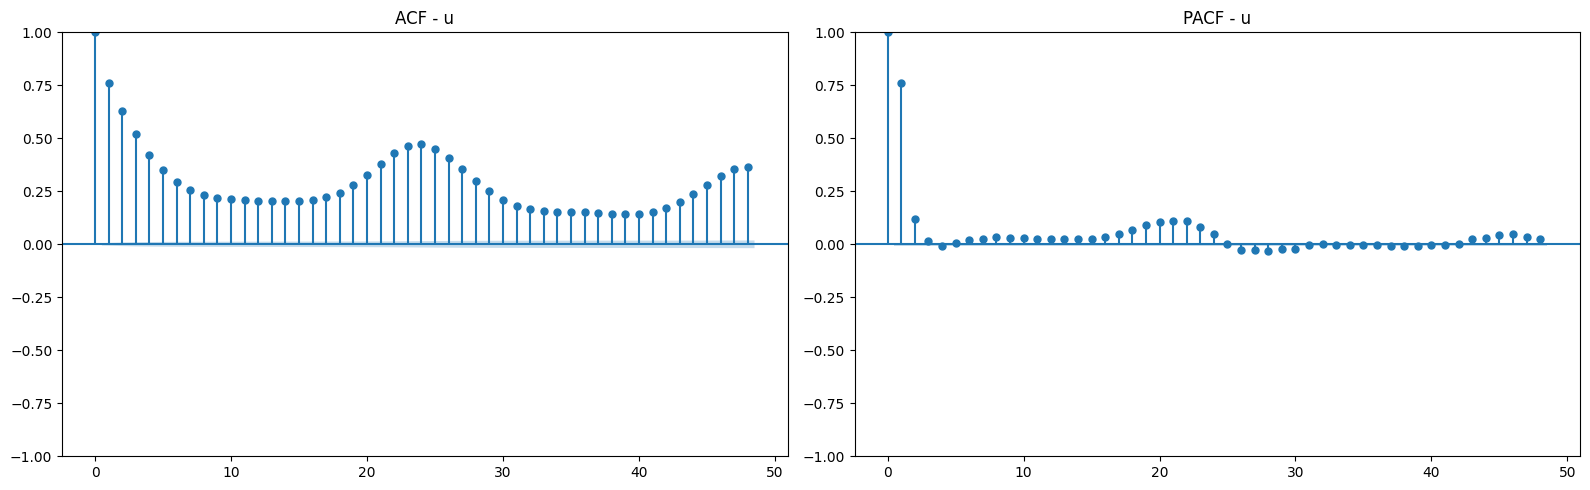

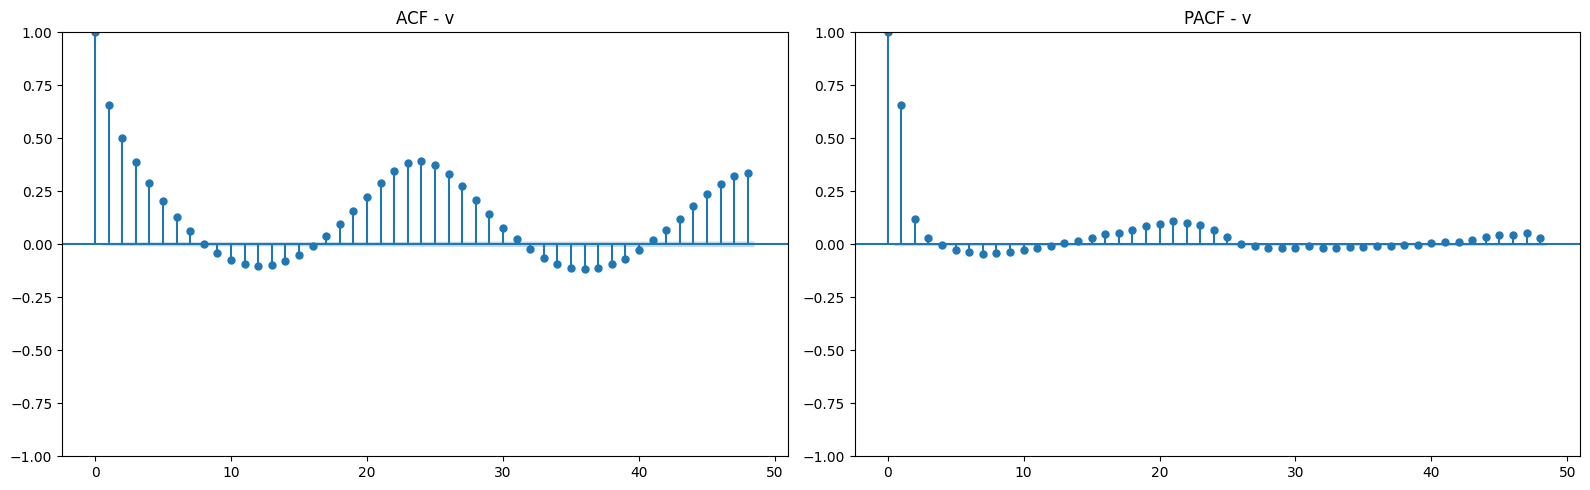

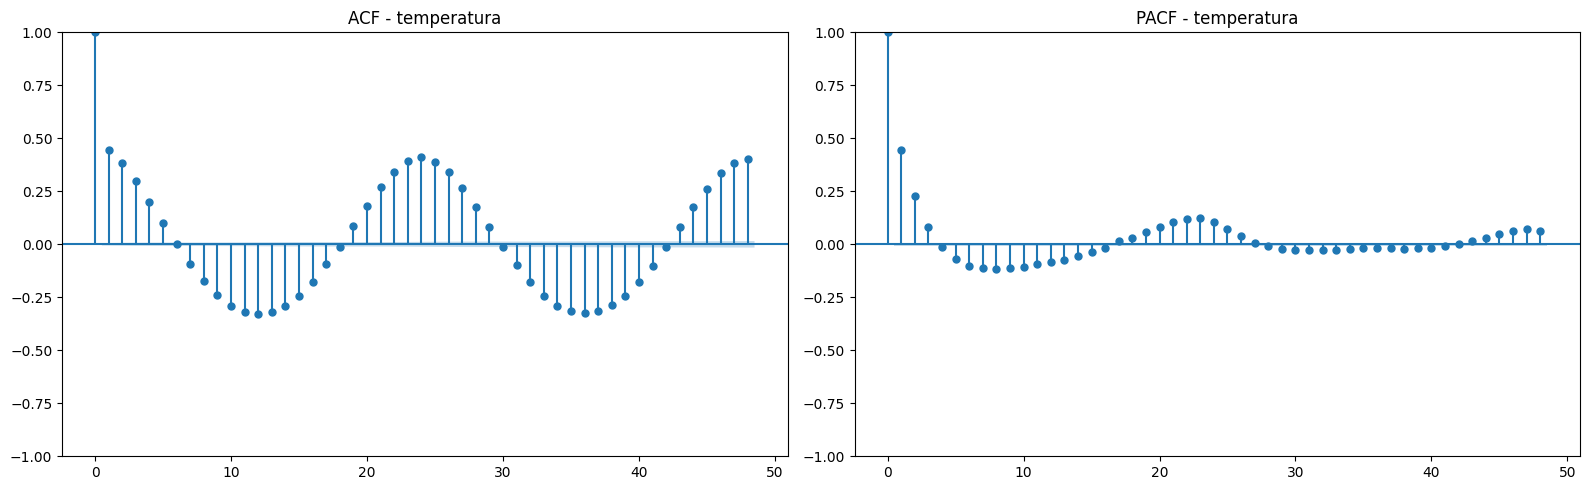

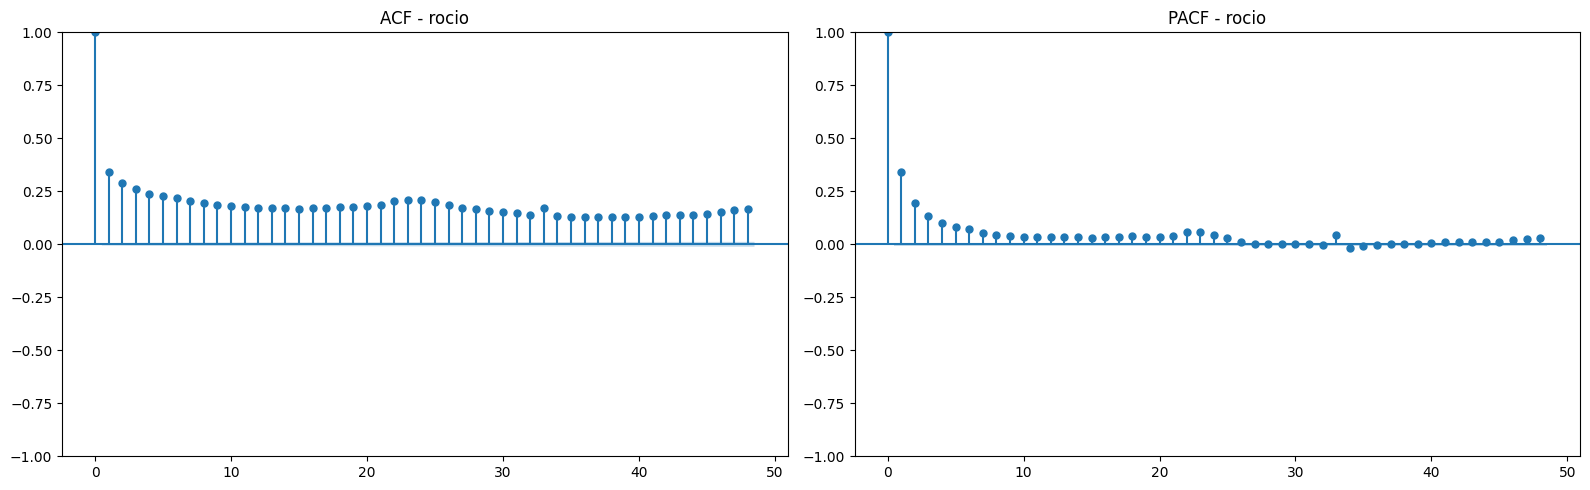

In [94]:
graficar_correlaciones(df_var, 'u')
graficar_correlaciones(df_var, 'v')
graficar_correlaciones(df_var, 'temperatura')
graficar_correlaciones(df_var, 'rocio') 

ACF (Autocorrelation Function)Mide la correlación total entre una observación actual ($Y_t$) y sus versiones pasadas ($Y_{t-k}$).
Para qué sirve: Identifica patrones de estacionalidad y persistencia. Si ves "olas" o picos que se repiten en intervalos fijos, tienes un ciclo (como el diario en tus datos).
Intuición: ¿Qué tanto se parece el viento de hoy a las 2:00 PM con el de ayer a las 2:00 PM, considerando toda la inercia de las horas intermedias?

PACF (Partial Autocorrelation Function)Mide la correlación directa entre $Y_t$ y $Y_{t-k}$, eliminando el efecto de los retardos intermedios.
Para qué sirve: Es la herramienta clave para determinar el orden del modelo ($p$). Te dice exactamente qué rezagos aportan información nueva y cuáles son solo "ecos" de rezagos anteriores.
Intuición: Si el viento de hace 1 hora explica el de ahora, y el de hace 2 horas también, la PACF limpia la influencia de la hora 1 para ver si la hora 2 realmente aporta algo por sí sola.

**Análisis**

A. Estacionalidad Diaria Dominante (ACF)
En ambas variables (u y v), la ACF muestra un patrón sinusoidal con picos claros en el lag 24 y lag 48.

Diagnóstico: Existe una correlación positiva muy fuerte con la misma hora del día anterior. Esto confirma que el ciclo circadiano (día/noche) es el motor principal de tu dataset. El modelo VAR debe "saber" qué hora es para ser preciso.

B. Memoria de Corto Plazo (PACF)
Observa los primeros lags en la PACF (de 1 a 5):

Diagnóstico: Hay barras muy altas que sobresalen de la franja azul (significancia estadística). Esto indica que el viento tiene una inercia física inmediata muy fuerte. Lo que pasó hace 1, 2 y 3 horas es fundamental para predecir la siguiente hora.

C. El "Efecto Eco" en el Lag 24 (PACF)
Nota que en la PACF hay un pequeño "salto" o barras significativas alrededor del lag 23-25.

Diagnóstico: Esto refuerza que, incluso eliminando las horas intermedias, la condición del viento de ayer a la misma hora sigue teniendo un peso predictivo directo.

**Conclusión para Modelo VAR**

Basado en estas gráficas, podemos concluir lo siguiente para la arquitectura del modelo:

Orden del Modelo ($p$): La PACF sugiere que un modelo con lags de 1 a 5 capturaría la mayor parte de la dinámica inmediata. Sin embargo, para capturar el ciclo diario completo, los criterios de información (AIC/BIC) podrían sugerir un $p$ más alto (cercano a 24).

Validez del VAR: Al ver que ambas variables (u y v) tienen estructuras de autocorrelación similares pero con amplitudes distintas, el VAR es ideal porque podrá modelar cómo la componente u del pasado afecta a la v del futuro y viceversa.

No hay Ruido Blanco: Las barras fuera de la zona azul confirman que tus datos no son aleatorios; contienen información estructurada que puede ser aprendida por el modelo

LAS VARIABLES SON ESTACIONARIAS, POR LO TANTO SE PUEDE APLICAR EL MODELO VAR.

In [95]:
# 1. Seleccionamos estrictamente u y v para evitar el error anterior
variables_var = ['u', 'v', 'temperatura', 'rocio']
df_modelo = df_var[variables_var].copy()

# 2. Inicializamos el escalador
scaler = StandardScaler()

# 3. Ajustamos y transformamos los datos
# Es vital mantener el índice de fechas original para el modelo VAR
datos_escalados = scaler.fit_transform(df_modelo)
df_escalado = pd.DataFrame(datos_escalados, columns=variables_var, index=df_modelo.index)

print("Medias tras el escalamiento (deberían ser ~0):")
print(df_escalado.mean())

Medias tras el escalamiento (deberían ser ~0):
u             -2.443344e-17
v              1.075071e-17
temperatura    1.368273e-16
rocio          2.472664e-16
dtype: float64


In [101]:
# Variables endógenas y exógenas
df_endog = df_escalado[['u', 'v']]
df_exog = df_escalado[['temperatura', 'rocio']]

# 1. Instanciamos el modelo con los datos ya escalados y sólo con las variables endógenas
modelo_var = VAR(df_endog)

# 2. Ejecutamos la búsqueda del mejor lag evaluando hasta 48 horas
print("Calculando criterios de información... (esto puede tardar unos segundos por el volumen de datos)")
seleccion_lags = modelo_var.select_order(maxlags=48)

# 3. Imprimimos el resumen de la selección
print(seleccion_lags.summary())

c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Calculando criterios de información... (esto puede tardar unos segundos por el volumen de datos)
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0     -0.03751    -0.03735      0.9632    -0.03746
1       -1.457      -1.457      0.2328      -1.457
2       -1.483      -1.482      0.2270      -1.482
3       -1.483      -1.482      0.2269      -1.483
4       -1.484      -1.482      0.2268      -1.483
5       -1.485      -1.483      0.2265      -1.484
6       -1.487      -1.485      0.2261      -1.486
7       -1.490      -1.488      0.2254      -1.489
8       -1.493      -1.491      0.2246      -1.493
9       -1.496      -1.493      0.2240      -1.495
10      -1.498      -1.495      0.2236      -1.497
11      -1.499      -1.496      0.2233      -1.498
12      -1.501      -1.496      0.2230      -1.499
13      -1.502      -1.498      0.2227      -1.501
14      -1.504      -1.499      0.22

In [102]:
from statsmodels.tsa.statespace.varmax import VARMAX
# Entrenamos el modelo con el lag sugerido y agregando las variables exógenas
lag_optimo = 48
resultados_var = modelo = VARMAX(
    endog=df_endog,
    exog=df_exog,
    order=(lag_optimo, 0)  # (p, q)
).fit(disp=False)
# Mostramos un resumen estadístico (opcional, será extenso)
print(resultados_var.summary())

c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


KeyboardInterrupt: 

In [16]:
from statsmodels.stats.stattools import durbin_watson

# 1. Extraemos los residuos del modelo entrenado
residuos = resultados_var.resid

# 2. Prueba de Durbin-Watson
out_dw = durbin_watson(residuos)
print("--- Diagnóstico de Autocorrelación de Residuos (Durbin-Watson) ---")
for col, val in zip(variables_var, out_dw):
    print(f"Componente {col}: {val:.4f} (Ideal: ~2.0)")

# 3. Prueba de Estabilidad (Raíces del sistema)
print("\n--- Diagnóstico de Estabilidad ---")
is_stable = resultados_var.is_stable()
print(f"¿Es el modelo matemáticamente estable?: {'SÍ' if is_stable else 'NO - Peligro de divergencia'}")

--- Diagnóstico de Autocorrelación de Residuos (Durbin-Watson) ---
Componente u: 2.0009 (Ideal: ~2.0)
Componente v: 2.0009 (Ideal: ~2.0)

--- Diagnóstico de Estabilidad ---
¿Es el modelo matemáticamente estable?: SÍ


In [17]:
# 1. Extraer el contexto (los últimos 'p' datos) necesario para predecir
# Como nuestro lag_optimo es 48, necesitamos las últimas 48 horas de la serie
valores_previos = df_escalado.values[-lag_optimo:]

# 2. Generar el pronóstico para la ventana de 6 horas
# 'steps=6' indica el horizonte de predicción
prediccion_escalada = resultados_var.forecast(y=valores_previos, steps=6)

In [18]:
# 3. Revertir el escalamiento para volver a nudos (kt)
prediccion_nudos = scaler.inverse_transform(prediccion_escalada)

In [19]:
# 4. Crear un DataFrame con las componentes predichas
df_prediccion = pd.DataFrame(prediccion_nudos, columns=['u_pred', 'v_pred'])

# 5. Reconstrucción de Magnitudes Físicas (Intensidad y Dirección)
# Intensidad (Magnitud del vector)
df_prediccion['intensidad_kt'] = np.sqrt(df_prediccion['u_pred']**2 + df_prediccion['v_pred']**2)

# Dirección Meteorológica (Ángulo de procedencia del viento, de 0 a 360 grados)
# Usamos -u y -v porque la convención meteorológica indica de DÓNDE viene el viento
df_prediccion['direccion_grados'] = (np.degrees(np.arctan2(-df_prediccion['u_pred'], -df_prediccion['v_pred'])) % 360)

# Redondeamos para tener el formato típico de un reporte METAR
df_prediccion = df_prediccion.round({'u_pred': 2, 'v_pred': 2, 'intensidad_kt': 0, 'direccion_grados': 0})

print("Pronóstico para la ventana de 6 horas:")
print(df_prediccion[['direccion_grados', 'intensidad_kt', 'u_pred', 'v_pred']])

Pronóstico para la ventana de 6 horas:
   direccion_grados  intensidad_kt  u_pred  v_pred
0             159.0            8.0   -2.98    7.91
1             153.0            7.0   -3.23    6.25
2             147.0            6.0   -3.15    4.84
3             138.0            5.0   -3.05    3.36
4             129.0            4.0   -2.77    2.23
5             114.0            3.0   -2.50    1.12


#### Entrenamiento del modelo VAR

In [103]:
df_escalado.head()

,u,v,temperatura,rocio
FECHA_REPORTE,,,,
2013-01-01 00:00:00,0.076857,-0.646661,-0.034428,-1.109379
2013-01-01 01:00:00,-0.355767,-0.976473,-0.238990,-0.810256
2013-01-01 02:00:00,-0.425518,-0.184354,-0.238990,-0.810256
2013-01-01 03:00:00,-0.137166,-0.561230,-0.852676,-0.810256
2013-01-01 04:00:00,-0.246466,-0.768852,-1.057239,-0.810256


In [20]:
train = df_escalado.loc[:'2024-12-31']
val   = df_escalado.loc['2025-01-01':'2025-12-31']
test  = df_escalado.loc['2026-01-01':]

# 2. Verificación de tamaños
print(f"Registros en Train (2013-2024): {len(train)}")
print(f"Registros en Validation (2025): {len(val)}")
print(f"Registros en Test (2026): {len(test)}")

Registros en Train (2013-2024): 105168
Registros en Validation (2025): 8736
Registros en Test (2026): 2371


In [21]:
# Instanciamos y entrenamos solo con TRAIN
modelo_train = VAR(train)
resultados_train = modelo_train.fit(48)

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


In [22]:
# Combinamos Train y Val solo para tener la historia accesible al iterar
historia = pd.concat([train, val])

# Listas para guardar las predicciones y los valores reales
predicciones_6h = []
reales_6h = []

# Iteramos sobre el año 2025 en saltos de 6 horas
# len(train) es nuestro índice de inicio para 2025
inicio_val = len(train)
fin_val = len(historia)
horizonte = 6

print("Iniciando Walk-Forward Validation sobre el set de 2025...")

for t in range(inicio_val, fin_val, horizonte):
    # Asegurarnos de no salirnos del dataset
    if t + horizonte > fin_val:
        break
        
    # Extraemos el contexto: Las 48 horas EXACTAMENTE ANTERIORES al punto t
    contexto_p = historia.iloc[t-48 : t].values
    
    # Predecimos 6 pasos hacia adelante
    pred_ventana = resultados_train.forecast(y=contexto_p, steps=horizonte)
    
    # Extraemos los valores reales correspondientes a esa misma ventana
    real_ventana = historia.iloc[t : t+horizonte].values
    
    predicciones_6h.append(pred_ventana)
    reales_6h.append(real_ventana)

# Convertimos las listas a arrays de numpy para calcular el error
preds_arr = np.vstack(predicciones_6h)
reales_arr = np.vstack(reales_6h)

# Desescalamos para calcular el error en nudos (kt) reales
preds_nudos = scaler.inverse_transform(preds_arr)
reales_nudos = scaler.inverse_transform(reales_arr)

# Calculamos el RMSE global de validación (2025)
rmse_u_val = np.sqrt(mean_squared_error(reales_nudos[:, 0], preds_nudos[:, 0]))
rmse_v_val = np.sqrt(mean_squared_error(reales_nudos[:, 1], preds_nudos[:, 1]))

print(f"\n--- Resultados Validación 2025 (Ventanas de 6h) ---")
print(f"Error RMSE para componente U: {rmse_u_val:.2f} nudos")
print(f"Error RMSE para componente V: {rmse_v_val:.2f} nudos")

Iniciando Walk-Forward Validation sobre el set de 2025...

--- Resultados Validación 2025 (Ventanas de 6h) ---
Error RMSE para componente U: 3.19 nudos
Error RMSE para componente V: 3.12 nudos


In [23]:
# 1. Reconstrucción de la Intensidad (Magnitud)
# Formula: sqrt(u^2 + v^2)
intensidad_real = np.sqrt(reales_nudos[:, 0]**2 + reales_nudos[:, 1]**2)
intensidad_pred = np.sqrt(preds_nudos[:, 0]**2 + preds_nudos[:, 1]**2)

# 2. Reconstrucción de la Dirección Meteorológica
# Formula: atan2(-u, -v) convertido a grados y en módulo 360
dir_real = (np.degrees(np.arctan2(-reales_nudos[:, 0], -reales_nudos[:, 1])) % 360)
dir_pred = (np.degrees(np.arctan2(-preds_nudos[:, 0], -preds_nudos[:, 1])) % 360)

# 3. Cálculo de Error en Intensidad
rmse_intensidad = np.sqrt(mean_squared_error(intensidad_real, intensidad_pred))
mae_intensidad = mean_absolute_error(intensidad_real, intensidad_pred)

# 4. Cálculo del Error Circular para la Dirección
# Diferencia angular absoluta
diff_angular = np.abs(dir_real - dir_pred)
# El error real es el camino más corto en el círculo
error_circular = np.minimum(diff_angular, 360 - diff_angular)

# Usamos MAE (Error Absoluto Medio) porque en grados es mucho más interpretable que el RMSE
mae_direccion = np.mean(error_circular)

print("--- Validación Operacional 2025 (Ventana 6h) ---")
print(f"Error RMSE Intensidad: {rmse_intensidad:.2f} nudos")
print(f"Error MAE  Intensidad: {mae_intensidad:.2f} nudos")
print("-" * 45)
print(f"Error Medio (MAE) Dirección: {mae_direccion:.2f} grados")

--- Validación Operacional 2025 (Ventana 6h) ---
Error RMSE Intensidad: 3.13 nudos
Error MAE  Intensidad: 2.29 nudos
---------------------------------------------
Error Medio (MAE) Dirección: 45.02 grados


Evaluación Walk-Forward por Horizonte de Pronóstico (Forecast Horizon Evaluation).Un modelo autorregresivo acumula error recursivamente: predecir la hora $t+1$ es más fácil que predecir la hora $t+6$. Si promediamos todo el error del 2025 en un solo número, estamos enmascarando la curva de degradación del modelo.

1. La Estrategia: Walk-Forward con Análisis por Horizonte

En lugar de evaluar "ventanas bloque" estáticas, simularemos el paso del tiempo hora a hora durante todo el 2025.
Por cada hora $t$ del año 2025:

- Le damos al modelo los últimos $48$ registros (hasta $t$).
- El modelo proyecta $h_1, h_2, h_3, h_4, h_5$ y $h_6$.
- Almacenamos cada predicción en "canastas" separadas según su horizonte ($h$).- - Avanzamos a $t+1$ y repetimos.

Al final, no tendrás un solo RMSE, sino 6 valores de RMSE, uno para cada hora del horizonte. 

In [24]:
# 1. Preparación del entorno de simulación
historia = pd.concat([train, val])
inicio_val = len(train)
fin_val = len(historia)
horizonte = 6

# 2. Diccionarios para almacenar errores por cada "paso" hacia adelante (1 a 6)
# Usaremos listas para almacenar los valores u, v predichos vs reales
resultados_h = {h: {'pred_u': [], 'pred_v': [], 'real_u': [], 'real_v': []} for h in range(1, horizonte + 1)}

print("Ejecutando Inferencia Continua 2025...")

# 3. Bucle Walk-Forward (Avanza hora a hora)
for t in range(inicio_val, fin_val - horizonte):
    # Contexto: Las 48 horas anteriores
    contexto = historia.iloc[t - 48 : t].values
    
    # Inferencia: Predicción de las próximas 6 horas
    pred_6h = resultados_train.forecast(y=contexto, steps=horizonte)
    real_6h = historia.iloc[t : t + horizonte].values
    
    # Revertir la escala de inmediato para guardar magnitudes físicas reales (Nudos)
    pred_6h_nudos = scaler.inverse_transform(pred_6h)
    real_6h_nudos = scaler.inverse_transform(real_6h)
    
    # 4. Distribución en los horizontes (h=1, h=2... h=6)
    for h_idx in range(horizonte):
        paso = h_idx + 1
        # Guardamos u y v predichos
        resultados_h[paso]['pred_u'].append(pred_6h_nudos[h_idx, 0])
        resultados_h[paso]['pred_v'].append(pred_6h_nudos[h_idx, 1])
        # Guardamos u y v reales
        resultados_h[paso]['real_u'].append(real_6h_nudos[h_idx, 0])
        resultados_h[paso]['real_v'].append(real_6h_nudos[h_idx, 1])

print("Simulación completada. Procesando métricas por horizonte...")

Ejecutando Inferencia Continua 2025...
Simulación completada. Procesando métricas por horizonte...


In [25]:
# DataFrame para estructurar el reporte final
reporte_errores = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizonte + 1)], 
                               columns=['RMSE_u', 'RMSE_v', 'MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])

for h in range(1, horizonte + 1):
    # Convertimos a arrays para cálculo vectorizado
    p_u = np.array(resultados_h[h]['pred_u'])
    p_v = np.array(resultados_h[h]['pred_v'])
    r_u = np.array(resultados_h[h]['real_u'])
    r_v = np.array(resultados_h[h]['real_v'])
    
    # Métricas Base
    rmse_u = np.sqrt(mean_squared_error(r_u, p_u))
    rmse_v = np.sqrt(mean_squared_error(r_v, p_v))
    
    # Reconstrucción de Intensidad (kt)
    int_pred = np.sqrt(p_u**2 + p_v**2)
    int_real = np.sqrt(r_u**2 + r_v**2)
    mae_int = mean_absolute_error(int_real, int_pred)
    
    # Reconstrucción de Dirección (grados)
    dir_pred = (np.degrees(np.arctan2(-p_u, -p_v)) % 360)
    dir_real = (np.degrees(np.arctan2(-r_u, -r_v)) % 360)
    
    # Error circular mínimo
    diff = np.abs(dir_real - dir_pred)
    error_circ = np.minimum(diff, 360 - diff)
    mae_dir = np.mean(error_circ)
    
    # Almacenamos en el reporte
    reporte_errores.loc[f"Hora {h}"] = [rmse_u, rmse_v, mae_int, mae_dir]

print("\n--- REPORTE ESTRUCTURADO DE EVALUACIÓN (2025) ---")
print(reporte_errores.astype(float).round(2))


--- REPORTE ESTRUCTURADO DE EVALUACIÓN (2025) ---
        RMSE_u  RMSE_v  MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1    2.52    2.73                 1.75                   32.59
Hora 2    2.96    3.06                 2.11                   42.06
Hora 3    3.19    3.18                 2.31                   46.34
Hora 4    3.32    3.23                 2.40                   48.52
Hora 5    3.38    3.25                 2.45                   49.68
Hora 6    3.41    3.26                 2.47                   50.42


¿Qué es el Modelo de Persistencia?

En el análisis de series temporales y, de manera muy especial, en meteorología, el Modelo de Persistencia (también conocido como Naive Forecast o pronóstico ingenuo) es la línea base absoluta contra la cual se debe comparar cualquier algoritmo complejo.

Su lógica matemática es extremadamente simple: asume que el futuro será exactamente igual al presente. Si definimos el tiempo actual como $t$ y nuestro horizonte de predicción como $h$, la ecuación del modelo de persistencia es:

In [26]:
# 1. Diccionario para almacenar los resultados de la persistencia
persistencia_h = {h: {'pred_u': [], 'pred_v': [], 'real_u': [], 'real_v': []} for h in range(1, horizonte + 1)}

print("Ejecutando Inferencia de Persistencia 2025...")

# 2. Bucle Walk-Forward
for t in range(inicio_val, fin_val - horizonte):
    # El "presente" es exactamente la hora anterior al bloque de predicción (t-1)
    presente_escalado = historia.iloc[t - 1 : t].values
    
    # Desescalamos el presente para tenerlo en nudos
    presente_nudos = scaler.inverse_transform(presente_escalado)[0] # Array 1D [u, v]
    
    # Los valores reales de las próximas 6 horas
    real_6h = historia.iloc[t : t + horizonte].values
    real_6h_nudos = scaler.inverse_transform(real_6h)
    
    # 3. Distribución en los horizontes
    for h_idx in range(horizonte):
        paso = h_idx + 1
        # La predicción de persistencia es estática: siempre es el "presente"
        persistencia_h[paso]['pred_u'].append(presente_nudos[0])
        persistencia_h[paso]['pred_v'].append(presente_nudos[1])
        
        # Guardamos u y v reales
        persistencia_h[paso]['real_u'].append(real_6h_nudos[h_idx, 0])
        persistencia_h[paso]['real_v'].append(real_6h_nudos[h_idx, 1])

# 4. Cálculo de Métricas (Idéntico al reporte anterior)
reporte_persistencia = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizonte + 1)], 
                                    columns=['RMSE_u', 'RMSE_v', 'MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])

for h in range(1, horizonte + 1):
    p_u = np.array(persistencia_h[h]['pred_u'])
    p_v = np.array(persistencia_h[h]['pred_v'])
    r_u = np.array(persistencia_h[h]['real_u'])
    r_v = np.array(persistencia_h[h]['real_v'])
    
    rmse_u = np.sqrt(mean_squared_error(r_u, p_u))
    rmse_v = np.sqrt(mean_squared_error(r_v, p_v))
    
    int_pred = np.sqrt(p_u**2 + p_v**2)
    int_real = np.sqrt(r_u**2 + r_v**2)
    mae_int = mean_absolute_error(int_real, int_pred)
    
    dir_pred = (np.degrees(np.arctan2(-p_u, -p_v)) % 360)
    dir_real = (np.degrees(np.arctan2(-r_u, -r_v)) % 360)
    
    diff = np.abs(dir_real - dir_pred)
    error_circ = np.minimum(diff, 360 - diff)
    mae_dir = np.mean(error_circ)
    
    reporte_persistencia.loc[f"Hora {h}"] = [rmse_u, rmse_v, mae_int, mae_dir]

print("\n--- REPORTE LÍNEA BASE: PERSISTENCIA (2025) ---")
print(reporte_persistencia.astype(float).round(2))

Ejecutando Inferencia de Persistencia 2025...

--- REPORTE LÍNEA BASE: PERSISTENCIA (2025) ---
        RMSE_u  RMSE_v  MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1    2.82    3.16                 1.62                   31.52
Hora 2    3.59    3.86                 2.01                   45.51
Hora 3    4.13    4.30                 2.35                   54.65
Hora 4    4.56    4.59                 2.63                   61.38
Hora 5    4.84    4.84                 2.88                   66.58
Hora 6    5.05    5.03                 3.09                   70.76


El Modelo VAR muestra un desempeño significativamente mejor que la persistencia, especialmente a medida que avanzamos en el horizonte de predicción. Esto indica que el modelo está capturando patrones temporales y relaciones entre las componentes u y v que la persistencia no puede replicar.

#### Modelo LSTM

##### Particion de datos

In [107]:
# 1. Partición cronológica estricta usando el índice datetime
# Train: 2013 hasta finales de 2024
train_df = df_escalado.loc[:'2024-12-31']

# Val: Todo el año 2025 (para el Keras Tuner / Early Stopping)
val_df = df_escalado.loc['2025-01-01':'2025-12-31']

# Test: Datos del 2026 (Para evaluación final fuera de muestra)
test_df = df_escalado.loc['2026-01-01':]

# 2. Conversión a arrays NumPy (n_samples, features)
# Al tener u y v, automáticamente nos queda en formato 2D, cumpliendo el reshape(-1, 1) de tu notebook, pero multivariante
Xtrain_data = train_df[['u', 'v','temperatura','rocio']].to_numpy()
Xval_data = val_df[['u', 'v','temperatura','rocio']].to_numpy()
Xtest_data = test_df[['u', 'v','temperatura','rocio']].to_numpy()

# Outputs (solo 2 variables)
y_train = train_df[['u', 'v']].to_numpy()
y_val   = val_df[['u', 'v']].to_numpy()
y_test  = test_df[['u', 'v']].to_numpy()

print(f"Dimensiones Train: {Xtrain_data.shape} -> (Muestras, Variables)")
print(f"Dimensiones Val:   {Xval_data.shape}")
print(f"Dimensiones Test:  {Xtest_data.shape}")

Dimensiones Train: (105168, 4) -> (Muestras, Variables)
Dimensiones Val:   (8736, 4)
Dimensiones Test:  (2371, 4)


##### Generacion de secuencias para LSTM

In [108]:
# Parámetros metodológicos
n_back = 48  # Nuestra ventana óptima de rezagos (reemplaza al 15 de tu notebook)
batch_size_train = 256 # Un lote más grande acelera el entrenamiento en TF
batch_size_test = 1    # Como en tu notebook, batch_size=1 en test facilita la inferencia

# 1. Generador de Entrenamiento
train_generator = TimeseriesGenerator( Xtrain_data, y_train,
                                      length=n_back, batch_size=batch_size_train)

# 2. Generador de Validación
val_generator = TimeseriesGenerator(Xval_data, y_val, 
                                    length=n_back, batch_size=batch_size_train)

# 3. Generador de Prueba
test_generator = TimeseriesGenerator(Xtest_data, y_test, 
                                     length=n_back, batch_size=batch_size_test)

# --- Verificación de la estructura ---
x_batch, y_batch = train_generator[0]
print(f"\nGenerador configurado exitosamente.")
print(f"Estructura del lote X: {x_batch.shape} -> (Batch_size, n_back, features)")
print(f"Estructura del lote y: {y_batch.shape} -> (Batch_size, features)")


Generador configurado exitosamente.
Estructura del lote X: (256, 48, 4) -> (Batch_size, n_back, features)
Estructura del lote y: (256, 2) -> (Batch_size, features)


##### Entrenamiento del modelo LSTM

Estructura de la Red Neuronal:


c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 200)            │       164,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           402 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,402 (642.20 KB)

 Trainable params: 164,402 (642.20 KB)

 Non-trainable params: 0 (0.00 B)


Iniciando entrenamiento...
Epoch 1/25


c:\Users\Usuario\Documents\MAESTRÍA\Semestre 2\Deep learning\condapython3_9\.conda\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


411/411 ━━━━━━━━━━━━━━━━━━━━ 65s 154ms/step - loss: 132128.5312 - val_loss: 0.6582
Epoch 2/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 68s 165ms/step - loss: 2207.4802 - val_loss: 0.6210
Epoch 3/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 64s 155ms/step - loss: 16492.4297 - val_loss: 0.5975
Epoch 4/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 63s 153ms/step - loss: 0.7163 - val_loss: 0.5712
Epoch 5/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 66s 159ms/step - loss: 0.6786 - val_loss: 0.5512
Epoch 6/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 68s 165ms/step - loss: 0.6583 - val_loss: 0.5350
Epoch 7/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 65s 157ms/step - loss: 0.6399 - val_loss: 0.5210
Epoch 8/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 63s 153ms/step - loss: 0.6137 - val_loss: 0.5084
Epoch 9/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 64s 156ms/step - loss: 0.6174 - val_loss: 0.4926
Epoch 10/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 68s 166ms/step - loss: 0.5855 - val_loss: 0.4773
Epoch 11/25
411/411 ━━━━━━━━━━━━━━━━━━━━ 75s 183ms/step - loss: 0.5520 - val_loss: 0.4562
Epoch 12/25
411/41

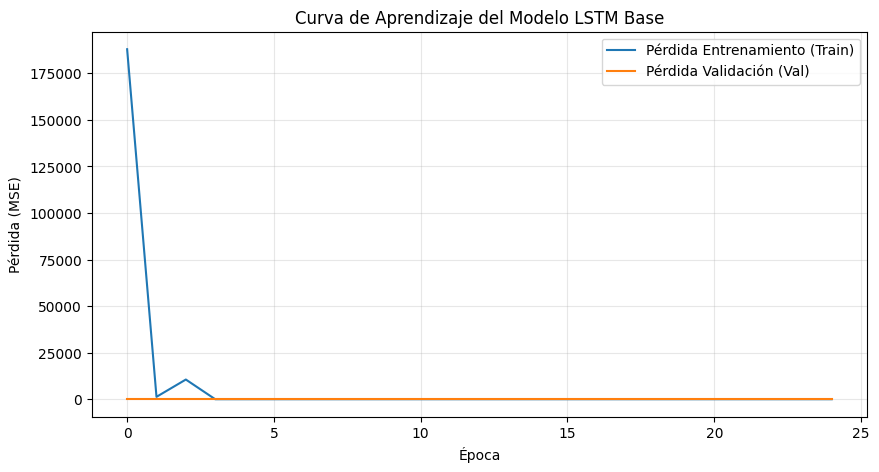

In [109]:
# Número de variables entradas (u, v, temperatura, rocio)
n_features = 4
n_outputs = 2  # Solo queremos predecir u y v para el próximo paso

# 1. Diseño de la Arquitectura del Modelo
model = Sequential()
# Capa LSTM: 200 neuronas, activación relu, recibe (48, 4)
model.add(LSTM(200, activation='relu', input_shape=(n_back, n_features)))
# Capa Densa: 2 neuronas de salida directa (para u y v en el tiempo t+1)
model.add(Dense(n_outputs))

# 2. Compilación
model.compile(optimizer='adam', loss='mse')
print("Estructura de la Red Neuronal:")
model.summary()

# 3. Entrenamiento (con validación en 2025 para monitorear)
num_epochs = 25

print("\nIniciando entrenamiento...")
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=num_epochs,
    verbose=1  # verbose=1 para que veas la barra de progreso
)

# 4. Visualización de la Curva de Aprendizaje
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Pérdida Entrenamiento (Train)')
plt.plot(history.history['val_loss'], label='Pérdida Validación (Val)')
plt.title('Curva de Aprendizaje del Modelo LSTM Base')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

##### Prueba de concepto a 6h

In [110]:
def predict_autoregressive(modelo, initial_window, exog_future, horizon):
    """
    Realiza el pronóstico iterativo hacia el futuro.
    - initial_window: Array con forma (1, n_back, n_features). Ej: (1, 48, 2)
    - exog_future: Variables exógenas futuras trmperatura y rocio. Forma (horizon, 2)
    - horizon: Cantidad de pasos a predecir (6 horas)
    """
    current_window = np.copy(initial_window)
    predictions = []
    
    for i in range(horizon):
        
        # 1. Predecir u, v
        next_uv = modelo.predict(current_window, verbose=0)  # (1, 2)
        
        predictions.append(next_uv[0])
        
        # 2. Tomar temperatura y rocío reales futuros
        temp_rocio = exog_future[i]  # (2,)
        
        # 3. Construir el nuevo timestep completo (4 variables)
        next_step_full = np.concatenate([next_uv[0], temp_rocio])  # (4,)
        
        # 4. Expandir a 3D
        next_step_full_3d = next_step_full.reshape(1, 1, 4)
        
        # 5. Actualizar ventana
        current_window = np.concatenate(
            [current_window[:, 1:, :], next_step_full_3d],
            axis=1
        )
    
    return np.array(predictions)  # (horizon, 2)

# --- Prueba del Motor de Inferencia ---
# Vamos a tomar las ÚLTIMAS 48 horas de tu set de validación (2025)
# para predecir las PRIMERAS 6 horas del test (2026).

horizonte_pred = 6

# Extraemos las últimas 48 horas
ultima_ventana_val = Xval_data[-n_back:] # Forma (48, 4) 4 VARIANLES (u, v, temp, rocio)

# Keras espera siempre la dimensión del 'batch' al principio. 
# Añadimos una dimensión extra -> (1, 48, 2)
ultima_ventana_val_3d = np.expand_dims(ultima_ventana_val, axis=0)
#Exógenas futuras: Tomamos las primeras 6 horas de temperatura y rocío del test
exog_future = Xtest_data[:horizonte_pred, 2:] # Forma (6, 2)

print("Iniciando pronóstico autoregresivo a 6 horas...")
forecast_escalado = predict_autoregressive(model, ultima_ventana_val_3d, exog_future, horizonte_pred)

print("\n¡Pronóstico generado con éxito!")
print(f"Dimensiones del forecast: {forecast_escalado.shape} -> (Horas, Variables u y v)")
print(forecast_escalado)

Iniciando pronóstico autoregresivo a 6 horas...

¡Pronóstico generado con éxito!
Dimensiones del forecast: (6, 2) -> (Horas, Variables u y v)
[[ 0.37127745  0.14895415]
 [ 0.17546633 -0.02264316]
 [-0.01995095 -0.22029105]
 [-0.14066833 -0.30322376]
 [-0.22931501 -0.4326682 ]
 [-0.23890486 -0.49878538]]


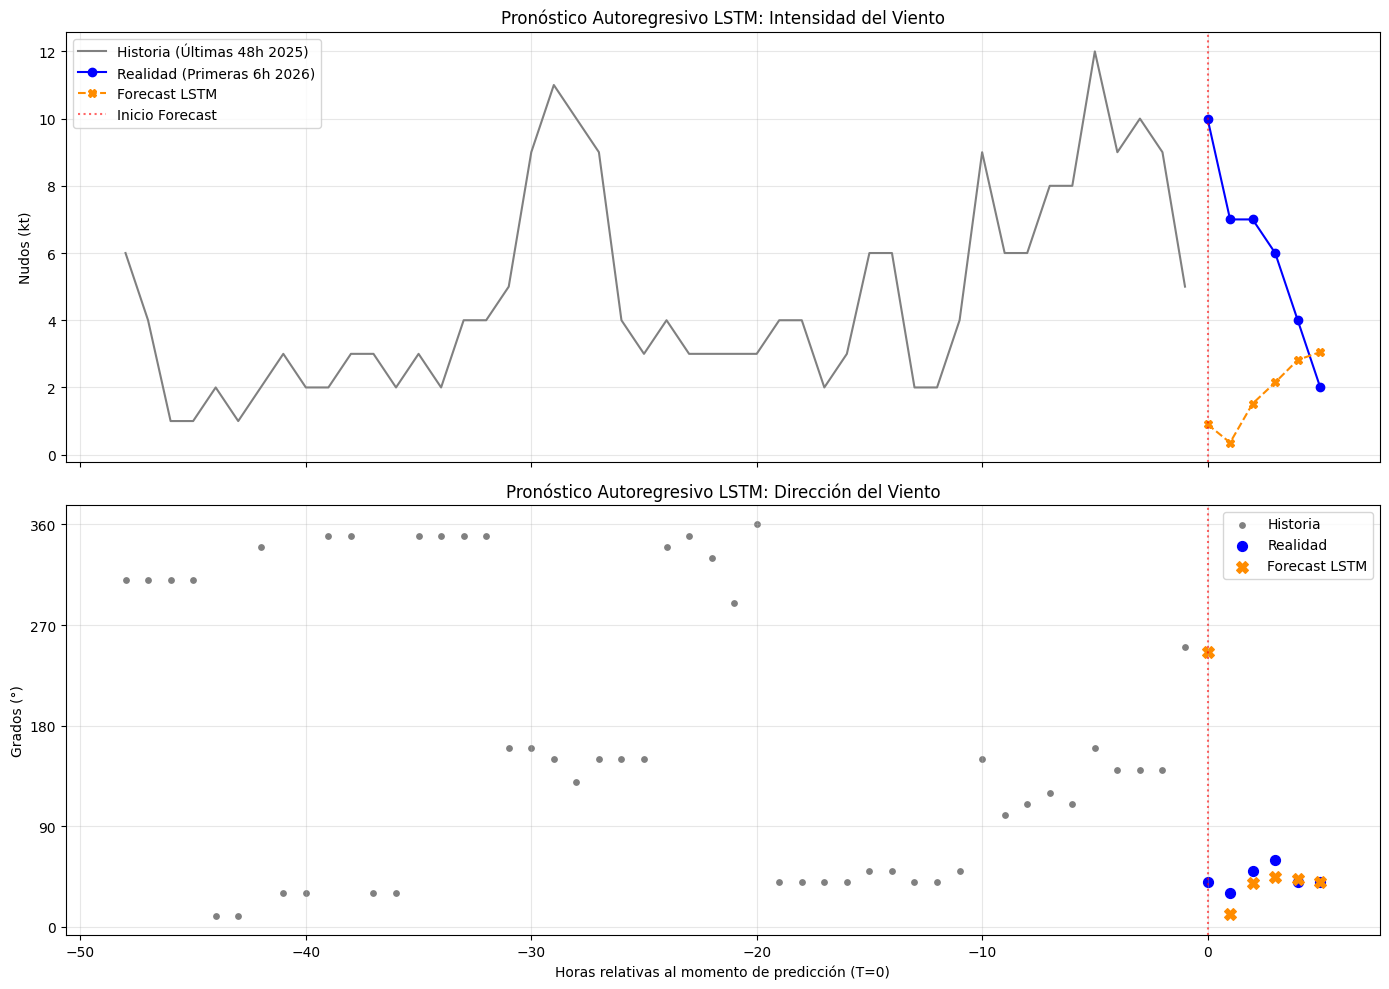

--- REPORTE DE PRONÓSTICO (T+1 a T+6) ---
Hora +1 | Real: 10.0kt @ 40° | Predicción LSTM: 0.9kt @ 246°
Hora +2 | Real: 7.0kt @ 30° | Predicción LSTM: 0.4kt @ 11°
Hora +3 | Real: 7.0kt @ 50° | Predicción LSTM: 1.5kt @ 39°
Hora +4 | Real: 6.0kt @ 60° | Predicción LSTM: 2.1kt @ 45°
Hora +5 | Real: 4.0kt @ 40° | Predicción LSTM: 2.8kt @ 43°
Hora +6 | Real: 2.0kt @ 40° | Predicción LSTM: 3.1kt @ 40°


In [111]:
# --- 1. Des-normalización de los datos ---
#añadir temperatura y rocío a forecast_escalado para poder usar scaler.inverse_transform
forescast_full = np.concatenate([forecast_escalado,Xtest_data[:horizonte_pred, 2:]], axis=1) # Forma (6, 4) con u, v, temp, rocío
# Pronóstico (las 6 horas generadas)
forecast_nudos = scaler.inverse_transform(forescast_full)[:, :2]  # Solo nos quedamos con u y v para convertir a nudos


# Valores Reales del Test (las primeras 6 horas de 2026 para comparar)
real_nudos = scaler.inverse_transform(Xtest_data[:horizonte_pred])[:, :2]  # Solo u y v para convertir a nudos

# Historia (las últimas 48 horas de 2025 para dar contexto en la gráfica)
historia_nudos = scaler.inverse_transform(ultima_ventana_val)[:, :2]  # Solo u y v para convertir a nudos

# --- 2. Función de Transformación Física ---
def uv_a_meteorologia(matriz_uv):
    """Convierte array de [u, v] a Intensidad y Dirección"""
    u = matriz_uv[:, 0]
    v = matriz_uv[:, 1]
    
    intensidad = np.sqrt(u**2 + v**2)
    direccion = (np.degrees(np.arctan2(-u, -v)) % 360)
    return intensidad, direccion

# Calculamos las variables operacionales
int_forecast, dir_forecast = uv_a_meteorologia(forecast_nudos)
int_real, dir_real = uv_a_meteorologia(real_nudos)
int_hist, dir_hist = uv_a_meteorologia(historia_nudos)

# --- 3. Preparación de Ejes Temporales para Graficar ---
# Eje X para la historia (índices del -48 al -1)
tiempo_historia = np.arange(-n_back, 0)
# Eje X para la predicción (índices del 0 al 5)
tiempo_pred = np.arange(0, horizonte_pred)

# --- 4. Visualización del Forecast ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Gráfico 1: Intensidad
ax1.plot(tiempo_historia, int_hist, color='gray', label='Historia (Últimas 48h 2025)')
ax1.plot(tiempo_pred, int_real, color='blue', marker='o', label='Realidad (Primeras 6h 2026)')
ax1.plot(tiempo_pred, int_forecast, color='darkorange', marker='X', linestyle='--', label='Forecast LSTM')

ax1.axvline(x=0, color='red', linestyle=':', alpha=0.6, label='Inicio Forecast')
ax1.set_title('Pronóstico Autoregresivo LSTM: Intensidad del Viento')
ax1.set_ylabel('Nudos (kt)')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Gráfico 2: Dirección
# Usamos scatter para la dirección para evitar líneas extrañas cruzando de 360 a 0
ax2.scatter(tiempo_historia, dir_hist, color='gray', s=15, label='Historia')
ax2.scatter(tiempo_pred, dir_real, color='blue', marker='o', s=50, label='Realidad')
ax2.scatter(tiempo_pred, dir_forecast, color='darkorange', marker='X', s=70, label='Forecast LSTM')

ax2.axvline(x=0, color='red', linestyle=':', alpha=0.6)
ax2.set_title('Pronóstico Autoregresivo LSTM: Dirección del Viento')
ax2.set_ylabel('Grados (°)')
ax2.set_yticks([0, 90, 180, 270, 360])
ax2.set_xlabel('Horas relativas al momento de predicción (T=0)')
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

# Imprimir tabla de valores para el reporte
print("--- REPORTE DE PRONÓSTICO (T+1 a T+6) ---")
for i in range(horizonte_pred):
    print(f"Hora +{i+1} | Real: {int_real[i]:.1f}kt @ {dir_real[i]:.0f}° | Predicción LSTM: {int_forecast[i]:.1f}kt @ {dir_forecast[i]:.0f}°")

##### Walk-Forward con LSTM

Evaluación Walk-Forward por Horizonte

In [113]:
def evaluar_modelo_lstm(modelo, data_escalada, scaler, seq_length=48, horizon=6, dataset_name="Test"):
    """
    Ejecuta el Walk-Forward autoregresivo sobre un dataset completo y calcula el MAE físico por horizonte.
    """
    print(f"Iniciando evaluación Walk-Forward para el set de {dataset_name}...")
    
    # Diccionarios para almacenar errores por horizonte
    resultados_h = {h: {'int_real': [], 'int_pred': [], 'dir_real': [], 'dir_pred': []} for h in range(1, horizon + 1)}
    
    inicio = seq_length
    fin = len(data_escalada)
    
    # Damos saltos del tamaño del horizonte para evaluar ventanas completas (acelera el proceso)
    for t in range(inicio, fin - horizon, horizon):
        
        # 1. Extraemos la ventana de contexto inicial (X)
        ventana_actual = data_escalada[t - seq_length : t]
        ventana_actual_3d = np.expand_dims(ventana_actual, axis=0)
        
        # 2. Generamos el forecast autoregresivo a 6 horas (reutilizamos la función del paso anterior) solo u y v
        forecast_escalado = predict_autoregressive(
            modelo, 
            ventana_actual_3d, 
            data_escalada[t : t + horizon, 2:],  #  exógenas futuras
            horizon
        )
        
        
        # 3. Extraemos los valores reales (4variables)
        real_escalado = data_escalada[t : t + horizon]
        
        # 4. Des-normalizamos a nudos

        #Reconstruir variables completas
        forecast_full = np.concatenate([forecast_escalado, real_escalado[:, 2:]], axis=1)
        #desnormalización correcta
        forecast_nudos = scaler.inverse_transform(forecast_full)[:, :2]  # Solo u y v para convertir a nudos
        real_nudos = scaler.inverse_transform(real_escalado)[:, :2]  # Solo u y v para convertir a nudos

        # 5. Transformación Física y almacenamiento por hora
        for h_idx in range(horizon):
            paso = h_idx + 1
            
            # Cálculo Real
            u_r, v_r = real_nudos[h_idx, 0], real_nudos[h_idx, 1]
            int_r = np.sqrt(u_r**2 + v_r**2)
            dir_r = (np.degrees(np.arctan2(-u_r, -v_r)) % 360)
            
            # Cálculo Predicho
            u_p, v_p = forecast_nudos[h_idx, 0], forecast_nudos[h_idx, 1]
            int_p = np.sqrt(u_p**2 + v_p**2)
            dir_p = (np.degrees(np.arctan2(-u_p, -v_p)) % 360)
            
            # Guardamos
            resultados_h[paso]['int_real'].append(int_r)
            resultados_h[paso]['int_pred'].append(int_p)
            resultados_h[paso]['dir_real'].append(dir_r)
            resultados_h[paso]['dir_pred'].append(dir_p)

    # --- Consolidación del Reporte ---
    reporte = pd.DataFrame(index=[f"Hora {h}" for h in range(1, horizon + 1)], 
                           columns=['MAE_Intensidad (kt)', 'MAE_Direccion (grados)'])
    
    for h in range(1, horizon + 1):
        # Arrays numpy para velocidad
        i_r = np.array(resultados_h[h]['int_real'])
        i_p = np.array(resultados_h[h]['int_pred'])
        
        # Arrays numpy para dirección
        d_r = np.array(resultados_h[h]['dir_real'])
        d_p = np.array(resultados_h[h]['dir_pred'])
        
        # MAE Intensidad
        mae_int = mean_absolute_error(i_r, i_p)
        
        # MAE Angular
        diff = np.abs(d_r - d_p)
        error_circ = np.minimum(diff, 360 - diff)
        mae_dir = np.mean(error_circ)
        
        reporte.loc[f"Hora {h}"] = [mae_int, mae_dir]
        
    print(f"\n--- REPORTE LSTM: {dataset_name.upper()} ---")
    print(reporte.astype(float).round(2))
    return reporte

# --- Ejecución ---
# Evaluamos Validación (2025)
reporte_val_lstm = evaluar_modelo_lstm(model, Xval_data, scaler, seq_length=n_back, horizon=horizonte_pred, dataset_name="Validación (2025)")

# Evaluamos Test (2026)
reporte_test_lstm = evaluar_modelo_lstm(model, Xtest_data, scaler, seq_length=n_back, horizon=horizonte_pred, dataset_name="Test (2026)")

Iniciando evaluación Walk-Forward para el set de Validación (2025)...

--- REPORTE LSTM: VALIDACIÓN (2025) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.77                   30.84
Hora 2                 2.12                   37.64
Hora 3                 2.29                   43.33
Hora 4                 2.39                   46.32
Hora 5                 2.41                   49.97
Hora 6                 2.36                   49.31
Iniciando evaluación Walk-Forward para el set de Test (2026)...

--- REPORTE LSTM: TEST (2026) ---
        MAE_Intensidad (kt)  MAE_Direccion (grados)
Hora 1                 1.76                   29.18
Hora 2                 2.15                   36.09
Hora 3                 2.16                   40.30
Hora 4                 1.95                   45.62
Hora 5                 2.11                   46.43
Hora 6                 2.20                   45.30


##### Visualizacion prediccion 120 horas en test y val

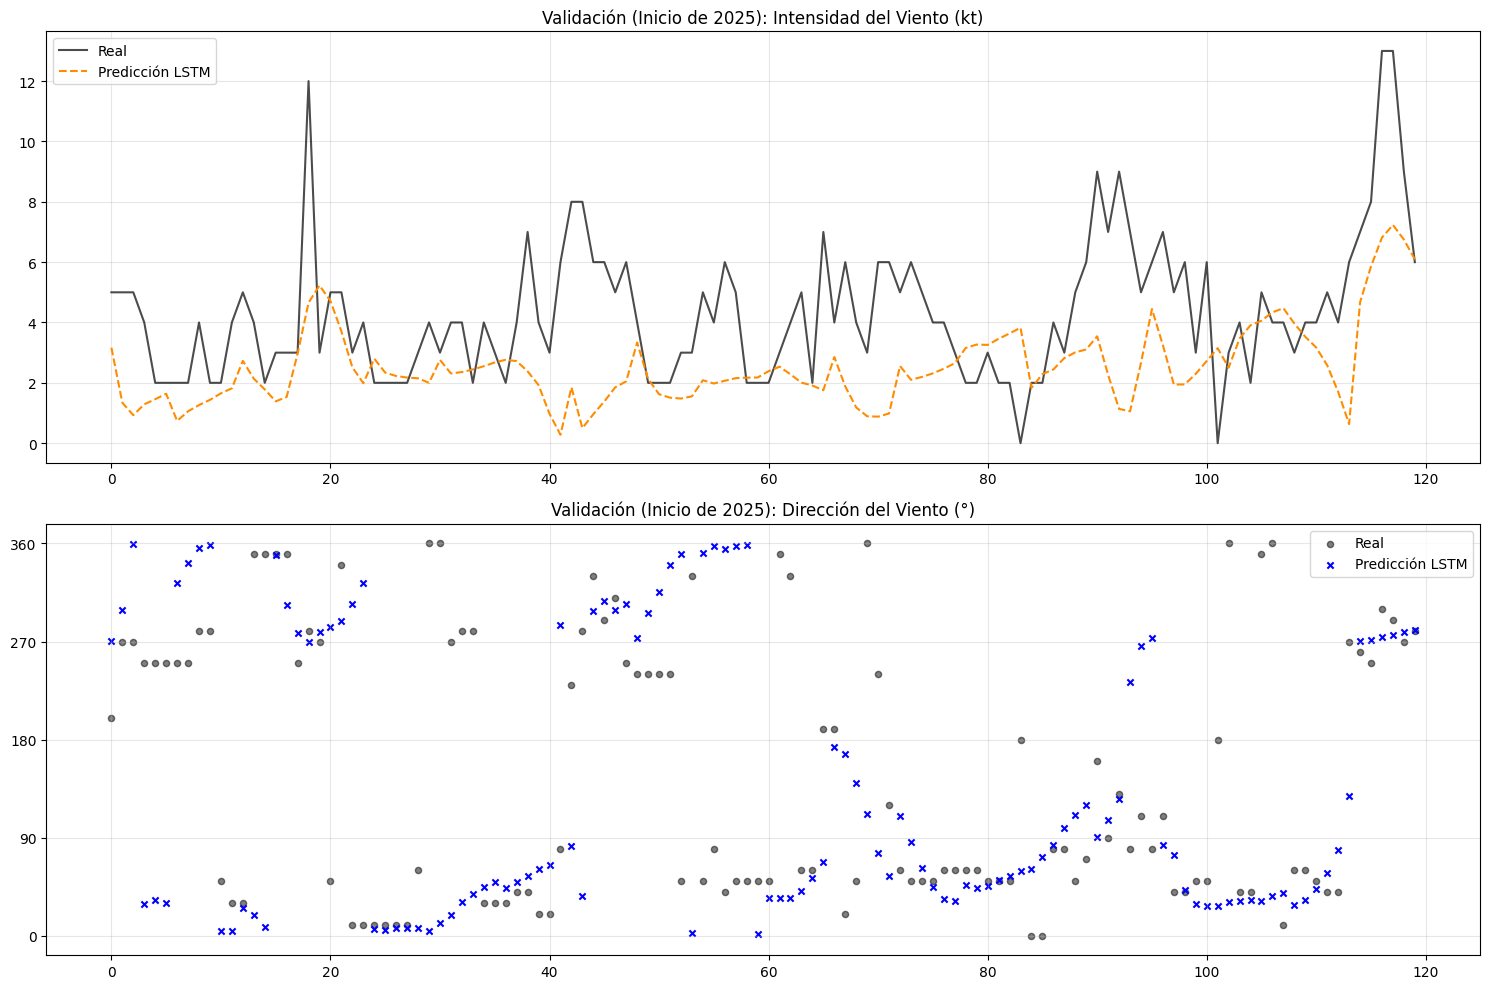

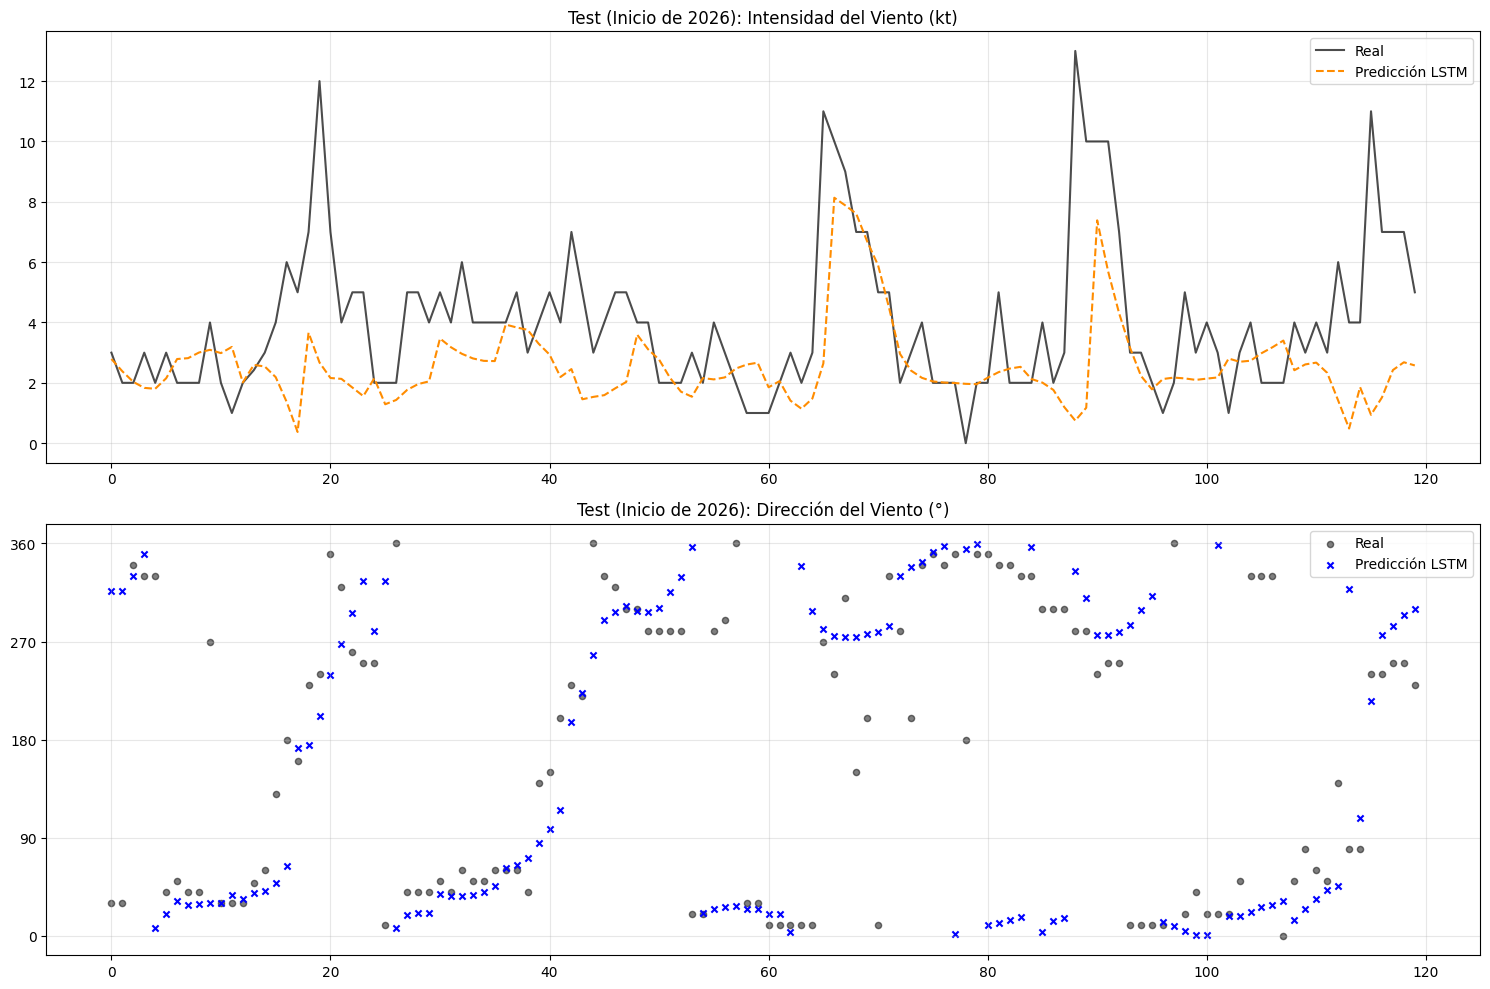

In [114]:
def visualizar_zoom_lstm(modelo, data_escalada, scaler, titulo, n_muestras=120, horizon=6):
    """
    Toma las primeras n_muestras, genera predicciones a 6h y grafica intensidad/dirección.
    """
    all_int_real, all_int_pred = [], []
    all_dir_real, all_dir_pred = [], []
    
    # Recorremos los primeros puntos para generar las predicciones
    for t in range(n_back, n_back + n_muestras, horizon):
        # 1. Preparar ventana X
        ventana = data_escalada[t - n_back : t]
        ventana_3d = np.expand_dims(ventana, axis=0)

        # 2. Exógenas futuras (temperatura, rocío)
        exog_future = data_escalada[t : t + horizon, 2:]

        # 3. Predict autoregresivo
        pred_esc = predict_autoregressive(modelo, ventana_3d, exog_future, horizon)
        real_esc = data_escalada[t : t + horizon]
        
        #4 reconstrucción completa para desescalar correctamente
        pred_full = np.concatenate([pred_esc, real_esc[:, 2:]], axis=1)
     
        
        # 4. Inversa y Transformación Física
        p_nudos = scaler.inverse_transform(pred_full)[:, :2]  # Solo u y v para convertir a nudos
        r_nudos = scaler.inverse_transform(real_esc)[:, :2]  # Solo u y v para convertir a nudos

        i_p, d_p = uv_a_meteorologia(p_nudos)
        i_r, d_r = uv_a_meteorologia(r_nudos)
        
        all_int_pred.extend(i_p); all_int_real.extend(i_r)
        all_dir_pred.extend(d_p); all_dir_real.extend(d_r)

    # Gráficos
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10))
    t_eje = np.arange(len(all_int_real))

    # Subplot 1: Intensidad
    ax1.plot(t_eje, all_int_real, label='Real', color='black', alpha=0.7)
    ax1.plot(t_eje, all_int_pred, label='Predicción LSTM', color='darkorange', linestyle='--')
    ax1.set_title(f'{titulo}: Intensidad del Viento (kt)')
    ax1.legend(); ax1.grid(True, alpha=0.3)

    # Subplot 2: Dirección
    ax2.scatter(t_eje, all_dir_real, label='Real', color='black', s=20, alpha=0.5)
    ax2.scatter(t_eje, all_dir_pred, label='Predicción LSTM', color='blue', marker='x', s=20)
    ax2.set_title(f'{titulo}: Dirección del Viento (°)')
    ax2.set_yticks([0, 90, 180, 270, 360])
    ax2.legend(); ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# --- Ejecución de las Gráficas ---

# 1. Gráfica para Validación (2025)
visualizar_zoom_lstm(model, Xval_data, scaler, "Validación (Inicio de 2025)")

# 2. Gráfica para Test (2026)
visualizar_zoom_lstm(model, Xtest_data, scaler, "Test (Inicio de 2026)")